In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import i0, i1, k0, k1
import CoolProp.CoolProp as CP
from scipy.interpolate import interp1d
from tabulate import tabulate
import pandas as pd
from IPython.display import display # Importamos display para Jupyter
from PIL import Image
import os


In [2]:
(400/200)**(1/3)

1.2599210498948732

# Intercambiador a contraflujo con recirculación

In [3]:
path_photo = os.path.join(os.getcwd(), 'fotos', 'diagrama_recirculacion.png')  # Asegúrate de que 'photo.jpg' esté en el mismo directorio que este script
if os.path.exists(path_photo):
    img = Image.open(path_photo)
    display(img)  # Muestra la imagen en Jupyter
else:    
    print(f"No se encontró la imagen en la ruta: {path_photo}")

No se encontró la imagen en la ruta: c:\Users\efect\Documents\Proyecto_Titulo_Enfriador-main\Enfriador\fotos\diagrama_recirculacion.png


Se toman los siguientes supuestos:
- La temperatura a la que sale el agua del tanque de circulación es la misma que la temperatura dentro del tanque
- La válvula de 3 vías se encuentra accionada de forma de que todo el caudal se recircula
- La bomba 1 no se encuentra en funcionamiento

Haciendo un balance de energía para el tanque de recirculación, se tiene:

$$
\dot{m}_{agua} c_{p} (T(t) - T_{out}(t)) = -\rho V c_p \frac{dT}{dt}
$$

Ahora, analizando el intercambiador de calor, se tiene que:

$$
\dot{Q}_{Hx} = \dot{m}_{agua} c_p (T(t) - T_{out}(t))
$$

El calor del intercambiador de calor puede ser calculado a partir de la eficiencia del intercambiador de calor y del calor máximo

$$
\dot{Q}_{Hx} = \varepsilon \dot{Q}_{max} = \varepsilon C_{min} (T(t) - T_{in,etanol})
$$

De esta forma, se tiene la siguiente EDO:

$$
\varepsilon C_{min} (T(t) - T_{in,etanol}) = -\rho V c_p \frac{dT}{dt}
$$

La cual tiene la siguiente solución considerando como condición inicial $T(0) = T_0$.

$$
T(t) = T_{in,etanol} + (T_0 - T_{in,etanol}) \cdot e^{(\frac{-\varepsilon C_{min}}{\rho V c_p }t)}
$$

Recordemos que la efectividad de un intercambiador a contraflujo se calcula a partir de la siguiente ecuación:

$$
\varepsilon = \frac{1 - e^{-NTU(1-C_r)}}{1 - C_re^{-NTU(1-C_r)}}
$$
 
Donde $NTU = \frac{UA}{C_{min}}$. El valor $UA$ se calcula de la siguiente forma:

$$
\frac{1}{UA} = \frac{1}{h_{agua}A_{agua}} + \frac{\ln(D_o/D_i)}{2\pi L k_{cobre}} + \frac{1}{h_{etanol}A_{etanol}}
$$

Donde $A_{agua}$ es el área del manto interior del tubo que contiene al agua, $A_{etanol}$ es el área del manto exterior del tubo que contiene al agua. El coeficiente de convección $h_{agua}$ se calcula a partir del númer de Nusselt para un tubo circular a calor constante, mientras que $h_{etanol}$ se calcula a partir del número de Nusselt para el flujo por una sección anular con calor constante

## Análisis Térmico del intercambiador de calor

In [4]:
class IntercambiadorContraflujo:

    '''Clase para modelar un intercambiador de calor de contraflujo.
    Se asumirá que el fluido caliente va por el tubo, y el frío por la sección anular'''

    def __init__(self, Q_hot, Q_cold, T_in_hot, T_in_cold, D_in_hot, D_out_hot, D_in_cold, D_out_cold, Length, k_tube, V_vaso):

        '''Recibe:
        Q_hot: Caudal volumétrico del fluido caliente (m^3/s)
        Q_cold: Caudal volumétrico del fluido frío (m^3/s)
        T_in_hot: Temperatura de entrada del fluido caliente (K)
        T_in_cold: Temperatura de entrada del fluido frío (K)
        D_in_hot: Diámetro interno del tubo del fluido caliente (m)
        D_out_hot: Diámetro externo del tubo del fluido caliente (m)
        D_in_cold: Diámetro interno del tubo del fluido frío (m)
        D_out_cold: Diámetro externo del tubo del fluido frío (m)
        Length: Longitud del intercambiador (m)
        k_tube: Conductividad térmica del material del tubo (W/m·K)'''

        self.Q_hot = Q_hot
        self.Q_cold = Q_cold
        self.T_in_hot = T_in_hot
        self.T_in_cold = T_in_cold
        self.D_in_hot = D_in_hot
        self.D_out_hot = D_out_hot
        self.D_in_cold = D_in_cold
        self.D_out_cold = D_out_cold
        self.Length = Length
        self.k_tube = k_tube
        self.P = 101325  # Presión atmosférica en Pa
        self.cold_fluid = 'Ethanol'
        self.cold_fluid_concentration = 0.01 # Concentración de etanol en el agua (1% etanol)
        self.V_vaso = V_vaso
        self.T_0_vaso = T_in_hot


    def calcular_propiedades_agua(self):
        self.rho_hot = CP.PropsSI('D', 'T', self.T_in_hot, 'P', self.P, 'Water')
        self.cp_hot = CP.PropsSI('C', 'T', self.T_in_hot, 'P', self.P, 'Water')
        self.mu_hot = CP.PropsSI('V', 'T', self.T_in_hot, 'P', self.P, 'Water')
        self.k_hot = CP.PropsSI('L', 'T', self.T_in_hot, 'P', self.P, 'Water')  
        self.beta_hot = CP.PropsSI('ISOBARIC_EXPANSION_COEFFICIENT', 'T', self.T_in_hot, 'P', self.P, 'Water')
        self.nu_hot = self.mu_hot / self.rho_hot
        self.m_dot_hot = self.rho_hot * self.Q_hot
        self.Re_hot = (4 * self.m_dot_hot) / (np.pi * (self.D_in_hot) * self.mu_hot)
        self.Pr_hot = self.cp_hot * self.mu_hot / self.k_hot

    def calcular_propiedades_solucion_etanol(self):

        vol_water = 1 - self.cold_fluid_concentration
        vol_ethanol = self.cold_fluid_concentration

        # ------------------------- Densidad -------------------------- 
        rho_etanol =  CP.PropsSI('D', 'T', self.T_in_cold, 'P', self.P, self.cold_fluid)
        rho_agua = CP.PropsSI('D', 'T', self.T_in_cold, 'P', self.P, 'Water')
        mass_etanol = rho_etanol * vol_ethanol
        mass_agua = rho_agua * vol_water
        mass_total = mass_etanol + mass_agua
        mass_frac_water = mass_agua / mass_total
        mass_frac_ethanol = mass_etanol / mass_total
        self.rho_cold = (mass_etanol + mass_agua) / (vol_ethanol + vol_water)

        # ------------------------- Capacidad calorífica --------------------------
        cp_etanol = CP.PropsSI('C', 'T', self.T_in_cold, 'P', self.P, self.cold_fluid)
        cp_agua = CP.PropsSI('C', 'T', self.T_in_cold, 'P', self.P, 'Water')
        self.cp_cold = (cp_etanol * mass_etanol + cp_agua * mass_agua) / (mass_etanol + mass_agua)

        # ------------------------- Viscosidad Dinámica --------------------------
        mu_etanol = CP.PropsSI('V', 'T', self.T_in_cold, 'P', self.P, self.cold_fluid)
        mu_agua = CP.PropsSI('V', 'T', self.T_in_cold, 'P', self.P, 'Water')
        self.mu_cold = float(np.exp(vol_water * np.log(mu_agua) + vol_ethanol * np.log(mu_etanol)))

        # ------------------------- Conductividad Térmica --------------------------
        k_etanol = CP.PropsSI('L', 'T', self.T_in_cold, 'P', self.P, self.cold_fluid)
        k_agua = CP.PropsSI('L', 'T', self.T_in_cold, 'P', self.P, 'Water')
        self.k_cold = mass_frac_water * k_agua + mass_frac_ethanol * k_etanol

        # ------------------------- Coeficiente de expansión isobárica --------------------------
        self.beta_cold = CP.PropsSI('ISOBARIC_EXPANSION_COEFFICIENT', 'T', self.T_in_cold, 'P', self.P, self.cold_fluid)


        # De aquí en adelante sigue normal
        self.nu_cold = self.mu_cold / self.rho_cold
        self.m_dot_cold = self.rho_cold * self.Q_cold
        self.D_h = self.D_in_cold - self.D_out_hot
        self.Re_cold = (4 * self.m_dot_cold) / (np.pi * (self.D_h) * self.mu_cold)
        self.Pr_cold = self.cp_cold * self.mu_cold / self.k_cold

        self.C_min = min(self.m_dot_hot * self.cp_hot, self.m_dot_cold * self.cp_cold)
        self.C_max = max(self.m_dot_hot * self.cp_hot, self.m_dot_cold * self.cp_cold)
        self.C_ratio = self.C_min / self.C_max

    def conveccion_tubo_interior(self):

        '''Calculamos el coeficiente de convección para el 
        fluido caliente, que va por el tubo interior.'''

        self.A_hot = np.pi * self.D_in_hot * self.Length

        if self.Re_hot < 2300:
            self.Nu_hot = 4.36
        else:
            self.Nu_hot = 0.023 * (self.Re_hot ** 0.8) * (self.Pr_hot ** 0.3)

        self.h_hot = self.Nu_hot * self.k_hot / self.D_in_hot

    def conveccion_seccion_anular(self):
        
        '''Calculamos el coeficiente de convección para el 
        fluido frío, que va por la sección anular.'''

        self.A_cold = np.pi * (self.D_out_hot * self.Length)

        self.tabla_8_3 = {
            "Di_Do": [0.05, 0.10, 0.20, 0.40, 0.60, 0.80],
            "Nu_ii": [17.81, 11.91, 8.499, 6.583, 5.912, 5.58],
            "Nu_oo": [4.792, 4.834, 4.833, 4.979, 5.099, 5.24]
        }

        Di_Do = self.D_out_hot / self.D_in_cold

        # Creamos las funciones de interpolación
        # 'kind=cubic' para curvas suaves o 'linear' para mayor seguridad con pocos datos
        interp_Nu_ii = interp1d(self.tabla_8_3["Di_Do"], self.tabla_8_3["Nu_ii"], kind='cubic', fill_value="extrapolate")
        # interp_Nu_oo = interp1d(self.tabla_8_3["Di_Do"], self.tabla_8_3["Nu_oo"], kind='cubic', fill_value="extrapolate")

        # Calculamos los Nusselt específicos para tu geometría
        self.Nu_ii_interp = float(interp_Nu_ii(Di_Do))
        # self.Nu_oo_interp = float(interp_Nu_oo(Di_Do))

        if self.Re_cold < 2300:
            factor_ajuste = 1.0
        else:
            factor_ajuste = 0.86 * ((self.D_out_hot / self.D_in_cold) ** (-0.16))

        self.h_cold = factor_ajuste * self.Nu_ii_interp * self.k_cold / self.D_h

    def calcular_UA(self):

        '''Calculamos el producto UA para cada fluido y el total.'''

        self.R_hot = 1 / (self.h_hot * self.A_hot)
        self.R_cold = 1 / (self.h_cold * self.A_cold)
        self.R_conduction = np.log(self.D_out_hot / self.D_in_hot) / (2 * np.pi * self.k_tube * self.Length)

        # Para intercambiadores en contraflujo, el UA total se calcula como:
        self.UA_total = 1 / (self.R_hot + self.R_cold + self.R_conduction)

    def calcular_efectividad(self):
        
        '''Calculamos la efectividad del intercambiador de calor.'''

        self.NTU = self.UA_total / self.C_min

        exp_term = np.exp(-self.NTU * (1 - self.C_ratio))

        if self.C_min == self.C_max:
            self.efectividad = self.NTU / (1 + self.NTU)
        else:
            self.efectividad = (1 - exp_term) / (1 - (self.C_ratio * exp_term))

    def calcular_temperaturas_salida(self):
        
        '''Calculamos las temperaturas de salida de ambos fluidos.'''

        self.Q_max = self.C_min * (self.T_in_hot - self.T_in_cold)
        self.Q_hx = self.efectividad * self.Q_max

        self.T_out_hot = self.T_in_hot - (self.Q_hx / (self.m_dot_hot * self.cp_hot))
        self.T_out_cold = self.T_in_cold + (self.Q_hx / (self.m_dot_cold * self.cp_cold))

    def grafico_intercambiador(self):
        
        '''Generamos un gráfico del intercambiador de calor.'''

        plt.figure(figsize=(10, 6))
        plt.plot([0, self.Length], [self.T_in_hot - 273.15, self.T_out_hot - 273.15], label='Agua', marker='o')
        plt.plot([0, self.Length], [self.T_in_cold - 273.15, self.T_out_cold - 273.15], label='Etanol', marker='o')
        plt.xlabel('Longitud del Intercambiador (m)')
        plt.ylabel('Temperatura (K)')
        plt.title('Perfil de Temperatura en el Intercambiador de Calor')
        plt.legend()
        plt.grid()
        plt.show()

    def edo_temperatura_vaso(self):
        self.t_values = np.linspace(0, 1800, 100)  # Simulamos por 30 min
        rho_vaso = CP.PropsSI('D', 'T', self.T_in_hot, 'P', self.P, 'Water')
        cp_vaso = CP.PropsSI('C', 'T', self.T_in_hot, 'P', self.P, 'Water')
        self.tau = (rho_vaso * self.V_vaso * cp_vaso) / (self.efectividad * self.C_min)

        self.T_t = self.T_in_cold + (self.T_0_vaso - self.T_in_cold) * np.exp(- self.t_values / self.tau)
        self

    def calcular_tiempo_enfriamiento(self):
        T_target = self.T_in_cold + 0.5
        self.t_enfriamiento = -self.tau * np.log((T_target - self.T_in_cold) / (self.T_0_vaso - self.T_in_cold))


    def resumen(self):

        '''Imprimimos un resumen de los resultados obtenidos.'''

        data = [
            ['T_in_hot (K)', self.T_in_hot - 273.15],
            ['T_out_hot (K)', self.T_out_hot - 273.15],
            ['T_in_cold (K)', self.T_in_cold - 273.15],
            ['T_out_cold (K)', self.T_out_cold - 273.15],
            ['Efectividad', self.efectividad],
            ['UA_total (W/K)', self.UA_total],
            ['Re_hot', self.Re_hot],
            ['Re_cold', self.Re_cold],
            ['h_hot (W/m^2K)', self.h_hot],
            ['h_cold (W/m^2K)', self.h_cold]
        ]
        headers = ['Parámetro', 'Valor']
        print(tabulate(data, headers=headers, tablefmt="grid"))

    def grafico_T_t(self):
        '''Generamos un gráfico de la temperatura del vaso en función del tiempo.'''

        plt.figure(figsize=(10, 6))
        plt.plot(self.t_values / 60, self.T_t - 273.15, label=rf'Temperatura del Vaso {self.V_vaso * 1e6:.0f} mL', marker='o')
        plt.xlabel('Tiempo (min)')
        plt.ylabel('Temperatura (°C)')
        plt.title('Enfriamiento del Vaso con el Intercambiador de Calor')
        plt.legend()
        plt.grid()
        plt.show()

    def ejecutar(self):
        
        '''Ejecutamos todos los cálculos en orden.'''

        self.calcular_propiedades_agua()
        self.calcular_propiedades_solucion_etanol()
        self.conveccion_tubo_interior()
        self.conveccion_seccion_anular()
        self.calcular_UA()
        self.calcular_efectividad()
        self.calcular_temperaturas_salida()
        self.edo_temperatura_vaso()
        self.calcular_tiempo_enfriamiento()
        # self.resumen()
        # self.grafico_intercambiador()


In [5]:
import numpy as np
import pandas as pd
from collections import deque

try:
    from IPython.display import display
except ImportError:
    display = print


# ============================================================
# CLASE DE RETARDO POR TRANSPORTE EN TUBERÍAS
# ============================================================

class DelayLine:
    def __init__(self, tau_s, dt_s, T_init):
        self.n = int(np.ceil(tau_s / dt_s))
        self.buffer = deque([T_init] * self.n)

    def step(self, T_in):
        if self.n <= 0:
            return T_in

        T_out = self.buffer.popleft()
        self.buffer.append(T_in)
        return T_out


# ============================================================
# INTERCAMBIADOR CONTRAFLUJO + TANQUE + RETARDO EN TUBERÍAS
# ============================================================

class IntercambiadorContraflujo:
    def __init__(
        self,
        Q_hot,
        Q_cold,
        T_in_hot,
        T_in_cold,
        D_in_hot,
        D_out_hot,
        D_in_cold,
        D_out_cold,
        Length,
        k_tube,
        V_tanque,
        L_tuberia_antes_hx,
        L_tuberia_despues_hx,
        T_objetivo,
        dt=0.05,
        t_max=3600
    ):
        self.Q_hot = Q_hot
        self.Q_cold = Q_cold
        self.T_in_hot = T_in_hot
        self.T_in_cold = T_in_cold

        self.D_in_hot = D_in_hot
        self.D_out_hot = D_out_hot
        self.D_in_cold = D_in_cold
        self.D_out_cold = D_out_cold

        self.Length = Length
        self.k_tube = k_tube
        self.V_tanque = V_tanque

        self.L_tuberia_antes_hx = L_tuberia_antes_hx
        self.L_tuberia_despues_hx = L_tuberia_despues_hx

        self.T_objetivo = T_objetivo
        self.dt = dt
        self.t_max = t_max

        self.rho_hot = 998.0
        self.cp_hot = 4180.0
        self.mu_hot = 1.0e-3
        self.k_hot = 0.60

        self.rho_cold = 1000.0
        self.cp_cold = 4180.0
        self.mu_cold = 1.2e-3
        self.k_cold = 0.55

        self.t_enfriamiento = np.nan
        self.historial = None

    def reynolds(self, rho, v, D_h, mu):
        return rho * v * D_h / mu

    def prandtl(self, cp, mu, k):
        return cp * mu / k

    def nusselt(self, Re, Pr):
        if Re < 2300:
            return 3.66
        elif Re > 10000:
            return 0.023 * Re**0.8 * Pr**0.4
        else:
            Nu_lam = 3.66
            Nu_turb = 0.023 * Re**0.8 * Pr**0.4
            factor = (Re - 2300) / (10000 - 2300)
            return Nu_lam + factor * (Nu_turb - Nu_lam)

    def calcular_UA(self):
        if self.D_in_cold <= self.D_out_hot:
            return np.nan, np.nan, np.nan, np.nan, np.nan

        A_hot_flow = np.pi * self.D_in_hot**2 / 4
        v_hot = self.Q_hot / A_hot_flow

        D_h_hot = self.D_in_hot
        Re_hot = self.reynolds(self.rho_hot, v_hot, D_h_hot, self.mu_hot)
        Pr_hot = self.prandtl(self.cp_hot, self.mu_hot, self.k_hot)
        Nu_hot = self.nusselt(Re_hot, Pr_hot)
        h_hot = Nu_hot * self.k_hot / D_h_hot

        A_cold_flow = np.pi * (self.D_in_cold**2 - self.D_out_hot**2) / 4
        v_cold = self.Q_cold / A_cold_flow

        D_h_cold = self.D_in_cold - self.D_out_hot
        Re_cold = self.reynolds(self.rho_cold, v_cold, D_h_cold, self.mu_cold)
        Pr_cold = self.prandtl(self.cp_cold, self.mu_cold, self.k_cold)
        Nu_cold = self.nusselt(Re_cold, Pr_cold)
        h_cold = Nu_cold * self.k_cold / D_h_cold

        A_transfer = np.pi * self.D_out_hot * self.Length

        R_conv_hot = self.D_out_hot / (h_hot * self.D_in_hot)
        R_cond = self.D_out_hot * np.log(self.D_out_hot / self.D_in_hot) / (2 * self.k_tube)
        R_conv_cold = 1 / h_cold

        U = 1 / (R_conv_hot + R_cond + R_conv_cold)
        UA = U * A_transfer

        return UA, U, Re_hot, Re_cold, A_transfer

    def calcular_salida_hx(self, T_hot_in_hx):
        UA, U, Re_hot, Re_cold, A_transfer = self.calcular_UA()

        if np.isnan(UA):
            return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan

        C_hot = self.rho_hot * self.Q_hot * self.cp_hot
        C_cold = self.rho_cold * self.Q_cold * self.cp_cold

        C_min = min(C_hot, C_cold)
        C_max = max(C_hot, C_cold)
        C_r = C_min / C_max

        NTU = UA / C_min

        if abs(1 - C_r) < 1e-8:
            epsilon = NTU / (1 + NTU)
        else:
            epsilon = (1 - np.exp(-NTU * (1 - C_r))) / (1 - C_r * np.exp(-NTU * (1 - C_r)))

        q = epsilon * C_min * (T_hot_in_hx - self.T_in_cold)

        T_hot_out = T_hot_in_hx - q / C_hot
        T_cold_out = self.T_in_cold + q / C_cold

        return T_hot_out, T_cold_out, U, NTU, Re_hot, Re_cold

    def ejecutar(self):
        A_hot_flow = np.pi * self.D_in_hot**2 / 4
        v_hot = self.Q_hot / A_hot_flow

        tau_antes = self.L_tuberia_antes_hx / v_hot
        tau_hx = (A_hot_flow * self.Length) / self.Q_hot
        tau_despues = self.L_tuberia_despues_hx / v_hot

        delay_antes_hx = DelayLine(tau_antes, self.dt, self.T_in_hot)
        delay_retorno = DelayLine(tau_hx + tau_despues, self.dt, self.T_in_hot)

        T_tanque = self.T_in_hot
        t = 0.0

        tiempo = []
        T_tanque_hist = []
        T_hx_in_hist = []
        T_hx_out_hist = []
        T_retorno_hist = []

        self.t_enfriamiento = np.nan

        while t <= self.t_max:
            T_hx_in = delay_antes_hx.step(T_tanque)

            T_hx_out, T_cold_out, U, NTU, Re_hot, Re_cold = self.calcular_salida_hx(T_hx_in)

            if np.isnan(T_hx_out):
                break

            T_retorno = delay_retorno.step(T_hx_out)

            dTdt = (self.Q_hot / self.V_tanque) * (T_retorno - T_tanque)
            T_tanque = T_tanque + dTdt * self.dt

            tiempo.append(t)
            T_tanque_hist.append(T_tanque)
            T_hx_in_hist.append(T_hx_in)
            T_hx_out_hist.append(T_hx_out)
            T_retorno_hist.append(T_retorno)

            if T_tanque <= self.T_objetivo:
                self.t_enfriamiento = t
                break

            t += self.dt

        self.historial = pd.DataFrame({
            "t_s": tiempo,
            "T_tanque_C": np.array(T_tanque_hist) - 273.15,
            "T_entrada_HX_C": np.array(T_hx_in_hist) - 273.15,
            "T_salida_HX_C": np.array(T_hx_out_hist) - 273.15,
            "T_retorno_tanque_C": np.array(T_retorno_hist) - 273.15
        })

        self.tau_antes_hx = tau_antes
        self.tau_hx = tau_hx
        self.tau_despues_hx = tau_despues
        self.tau_total = tau_antes + tau_hx + tau_despues

        self.U = U
        self.NTU = NTU
        self.Re_hot = Re_hot
        self.Re_cold = Re_cold

        return self


# ============================================================
# DATOS DE OPERACIÓN
# ============================================================

Q_cold = (60)/(5.8*2) * 0.001 / 60
T_in_hot = 20 + 273.15
T_in_cold = 4 + 273.15

T_objetivo_C = 8
T_objetivo = T_objetivo_C + 273.15

D_in_hot = (9.525 - 2*1) / 1000 # Diámetro interno del tubo del fluido caliente (m) https://oteroindustrial.cl/tubo-acero-inoxidable-con-costura-304-1.html
D_out_hot = 9.525 / 1000

Length = 0.9
k_tube = 45

# Según el esquema:
# Antes del intercambiador: 5 cm + 10 cm + 5 cm
# Después del intercambiador: 5 cm + 25 cm + 35 cm + 5 cm
L_tuberia_antes_hx = (5 + 10 + 5) / 100
L_tuberia_despues_hx = (5 + 25 + 35 + 5) / 100


# ============================================================
# PARÁMETROS A EVALUAR
# ============================================================

possible_water_flow_rates = np.array([1 * 0.001 / 60])
# Diámetros comerciales de cobre type L https://copper.org/applications/plumbing/cth/technical-data/tables/cth_table2b.php
possible_cold_inner_diameters = np.array([
    13.843,
    16.916,
    19.939,
    26.035,
    32.131,
    38.227,
    50.419,
    62.611,
    74.803,
    86.995,
    99.187,
    123.825,
    148.463,
    196.215,
    244.475,
    293.751
]) * 1e-3

possible_cold_outer_diameters = np.array([
    15.875,
    19.050,
    22.225,
    28.575,
    34.925,
    41.275,
    53.975,
    66.675,
    79.375,
    92.075,
    104.775,
    130.175,
    155.575,
    206.375,
    257.175,
    307.975
]) * 1e-3

possible_volumes = np.array([
    300, 400, 500, 600, 700, 800, 900, 1000
]) * 1e-6


# ============================================================
# SIMULACIÓN
# ============================================================

results = []
modelos = {}

for Q_hot in possible_water_flow_rates:
    for V in possible_volumes:
        for D_in_cold, D_out_cold in zip(possible_cold_inner_diameters, possible_cold_outer_diameters):

            intercambiador = IntercambiadorContraflujo(
                Q_hot=Q_hot,
                Q_cold=Q_cold,
                T_in_hot=T_in_hot,
                T_in_cold=T_in_cold,
                D_in_hot=D_in_hot,
                D_out_hot=D_out_hot,
                D_in_cold=D_in_cold,
                D_out_cold=D_out_cold,
                Length=Length,
                k_tube=k_tube,
                V_tanque=V,
                L_tuberia_antes_hx=L_tuberia_antes_hx,
                L_tuberia_despues_hx=L_tuberia_despues_hx,
                T_objetivo=T_objetivo,
                dt=0.05,
                t_max=3600
            )

            intercambiador.ejecutar()

            key = (Q_hot, V, D_in_cold, D_out_cold)
            modelos[key] = intercambiador

            results.append({
                "Q_hot (L/h)": round(Q_hot * 3600 * 1000, 2),
                "D_in_cold (mm)": round(D_in_cold * 1e3, 4),
                "D_out_cold (mm)": round(D_out_cold * 1e3, 4),
                "V_tanque (mL)": round(V * 1e6, 2),
                "T_objetivo (°C)": T_objetivo_C,
                "U (W/m2K)": round(intercambiador.U, 2),
                "NTU": round(intercambiador.NTU, 4),
                "Re_hot": round(intercambiador.Re_hot, 2),
                "Re_cold": round(intercambiador.Re_cold, 2),
                "tau antes HX (s)": round(intercambiador.tau_antes_hx, 3),
                "tau dentro HX (s)": round(intercambiador.tau_hx, 3),
                "tau después HX (s)": round(intercambiador.tau_despues_hx, 3),
                "tau total sistema (s)": round(intercambiador.tau_total, 3),
                "Tiempo de Enfriamiento (min:seg)": (
                    "No alcanza"
                    if np.isnan(intercambiador.t_enfriamiento)
                    else f"{int(intercambiador.t_enfriamiento // 60)}:{int(intercambiador.t_enfriamiento % 60):02d}"
                ),
                "Tiempo de Enfriamiento (seg)": (
                    np.nan
                    if np.isnan(intercambiador.t_enfriamiento)
                    else round(intercambiador.t_enfriamiento, 4)
                )
            })


# ============================================================
# RESULTADOS
# ============================================================

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1200)

df_resultados = pd.DataFrame(results)

df_validos = df_resultados.dropna(subset=["Tiempo de Enfriamiento (seg)"]).copy()

print("--- RESUMEN DE OPTIMIZACIÓN ---")
print(f"Total de configuraciones simuladas: {len(df_resultados)}")
print(f"Configuraciones que alcanzan {T_objetivo_C} °C: {len(df_validos)}")

if len(df_validos) > 0:
    indice_optimo = df_validos["Tiempo de Enfriamiento (seg)"].idxmin()
    configuracion_optima = df_resultados.loc[indice_optimo]

    print("\nCONFIGURACIÓN ÓPTIMA ENCONTRADA:")
    display(configuracion_optima.to_frame().T)

    print("\nTOP 5 MEJORES DISEÑOS:")
    top_5 = df_validos.sort_values(
        by="Tiempo de Enfriamiento (seg)",
        ascending=True
    ).head(5)

    display(top_5)
else:
    print("\nNinguna configuración alcanza la temperatura objetivo dentro del tiempo máximo.")
    display(df_resultados.sort_values(by="U (W/m2K)", ascending=False).head(5))


# ============================================================
# HISTORIAL DE LA CONFIGURACIÓN ÓPTIMA
# ============================================================

if len(df_validos) > 0:
    fila = df_resultados.loc[indice_optimo]

    Q_opt = fila["Q_hot (L/h)"] / 1000 / 3600
    V_opt = fila["V_tanque (mL)"] * 1e-6
    D_in_cold_opt = fila["D_in_cold (mm)"] * 1e-3
    D_out_cold_opt = fila["D_out_cold (mm)"] * 1e-3

    key_opt = (Q_opt, V_opt, D_in_cold_opt, D_out_cold_opt)
    modelo_optimo = modelos[key_opt]

    print("\nHISTORIAL TEMPORAL DE LA CONFIGURACIÓN ÓPTIMA:")
    display(modelo_optimo.historial.head(20))

    # Para guardar resultados:
    # df_resultados.to_csv("resultados_intercambiador_con_retardo_tuberias.csv", index=False)
    # modelo_optimo.historial.to_csv("historial_temporal_configuracion_optima.csv", index=False)

--- RESUMEN DE OPTIMIZACIÓN ---
Total de configuraciones simuladas: 128
Configuraciones que alcanzan 8 °C: 54

CONFIGURACIÓN ÓPTIMA ENCONTRADA:


,Q_hot (L/h),D_in_cold (mm),D_out_cold (mm),V_tanque (mL),T_objetivo (°C),U (W/m2K),NTU,Re_hot,Re_cold,tau antes HX (s),tau dentro HX (s),tau después HX (s),tau total sistema (s),Tiempo de Enfriamiento (min:seg),Tiempo de Enfriamiento (seg)
0,60.0,13.843,15.875,300.0,8,272.07,0.1054,2814.38,3914.26,0.534,2.402,1.868,4.803,5:17,317.35



TOP 5 MEJORES DISEÑOS:


,Q_hot (L/h),D_in_cold (mm),D_out_cold (mm),V_tanque (mL),T_objetivo (°C),U (W/m2K),NTU,Re_hot,Re_cold,tau antes HX (s),tau dentro HX (s),tau después HX (s),tau total sistema (s),Tiempo de Enfriamiento (min:seg),Tiempo de Enfriamiento (seg)
0,60.0,13.843,15.875,300.0,8,272.07,0.1054,2814.38,3914.26,0.534,2.402,1.868,4.803,5:17,317.35
1,60.0,16.916,19.050,300.0,8,220.81,0.0855,2814.38,3459.34,0.534,2.402,1.868,4.803,6:27,387.10
16,60.0,13.843,15.875,400.0,8,272.07,0.1054,2814.38,3914.26,0.534,2.402,1.868,4.803,6:41,401.25
32,60.0,13.843,15.875,500.0,8,272.07,0.1054,2814.38,3914.26,0.534,2.402,1.868,4.803,8:05,485.15
2,60.0,19.939,22.225,300.0,8,174.01,0.0674,2814.38,3104.41,0.534,2.402,1.868,4.803,8:06,486.70



HISTORIAL TEMPORAL DE LA CONFIGURACIÓN ÓPTIMA:


,t_s,T_tanque_C,T_entrada_HX_C,T_salida_HX_C,T_retorno_tanque_C
0,0.00,20.0,20.0,18.414466,20.0
1,0.05,20.0,20.0,18.414466,20.0
2,0.10,20.0,20.0,18.414466,20.0
3,0.15,20.0,20.0,18.414466,20.0
4,0.20,20.0,20.0,18.414466,20.0
5,0.25,20.0,20.0,18.414466,20.0
6,0.30,20.0,20.0,18.414466,20.0
7,0.35,20.0,20.0,18.414466,20.0
8,0.40,20.0,20.0,18.414466,20.0
9,0.45,20.0,20.0,18.414466,20.0


In [6]:
Q_cold*60*1000

5.172413793103448

## Análisis de la pérdida de carga

Para calcular las constantes de pérdida por singularidad, se utiliza la siguiente tabla:

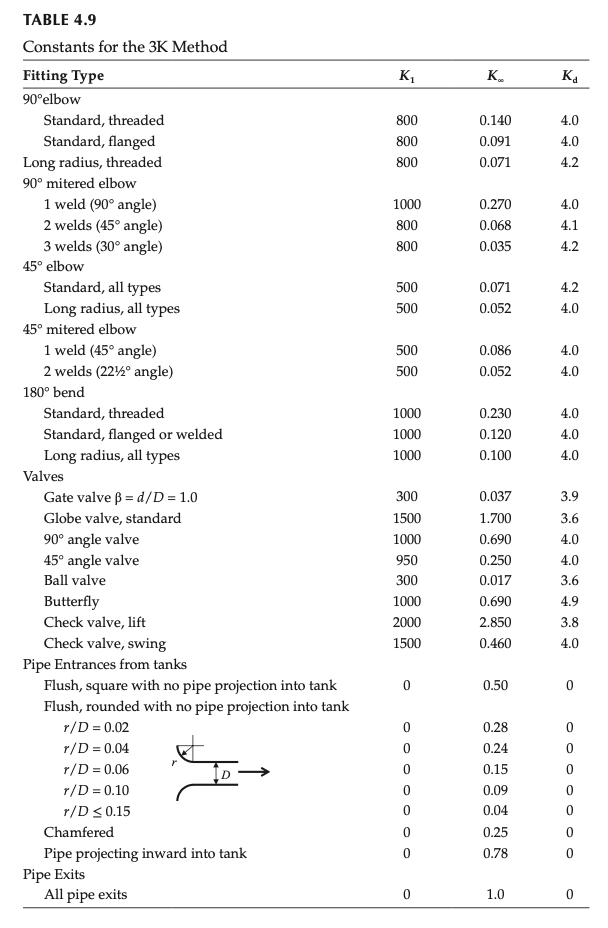

In [7]:
import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    display = print


# ============================================================
# USAR CONFIGURACIÓN ÓPTIMA DEL CÓDIGO TÉRMICO YA CORRIDO
# ============================================================

if "configuracion_optima" not in globals():
    if "df_validos" in globals() and len(df_validos) > 0:
        indice_optimo = df_validos["Tiempo de Enfriamiento (seg)"].idxmin()
        configuracion_optima = df_resultados.loc[indice_optimo]
    else:
        raise RuntimeError("Primero debes correr el código térmico para obtener configuracion_optima.")

Q_agua = configuracion_optima["Q_hot (L/h)"] / 1000 / 3600      # m3/s
Q_etanol = Q_cold                                               # m3/s

D_inox_in = D_in_hot                                            # m, agua por tubo interno inox
D_inox_out = D_out_hot                                          # m, diámetro externo tubo interno inox

D_cobre_in = configuracion_optima["D_in_cold (mm)"] * 1e-3      # m, diámetro interno tubo externo cobre
D_cobre_out = configuracion_optima["D_out_cold (mm)"] * 1e-3    # m, diámetro externo tubo externo cobre

L_agua_silicona_antes = L_tuberia_antes_hx
L_HX = Length
L_agua_silicona_despues = L_tuberia_despues_hx

# En el código térmico previo no se definieron largos de manguera del Lauda.

L_etanol_silicona_antes = 1.0
L_etanol_silicona_despues = 1.0
L_etanol_HX = L_HX

# Mangueras de silicona
D_agua_silicona_in = D_inox_in

# Ajusta este valor si conoces el diámetro interno real de las mangueras del Lauda
D_etanol_silicona_in = (15.875   -   2) /1000


# ============================================================
# PROPIEDADES FÍSICAS
# ============================================================

rho_agua = 998.0
mu_agua = 1.0e-3

rho_etanol = 1000.0
mu_etanol = 1.2e-3

g = 9.81


# ============================================================
# ALTURA GEOMÉTRICA
# ============================================================
# Para recirculación cerrada se deja en False.
# La altura no se considera como pérdida neta porque la subida y bajada se compensan.
# Solo usar True si existe diferencia neta entre succión y descarga.

INCLUIR_ALTURA = False
delta_z_agua = 0.0
delta_z_etanol = 0.0


# ============================================================
# RUGOSIDADES ABSOLUTAS APROXIMADAS
# ============================================================

EPS_SILICONA = 0.006e-3 
EPS_INOX = 0.015e-3  
EPS_COBRE = 0.0015e-3  




# En el anular del etanol hay pared interna de inox y pared externa de cobre
EPS_ANULAR_ETANOL = 0.5 * (EPS_INOX + EPS_COBRE)


# ============================================================
# PÉRDIDAS SINGULARES APROXIMADAS
# ============================================================

K_AGUA = {
    "entrada_succion": 0.5,
    "salida_retorno": 1.0,
    "codos_90": 6 * 0.9,
    "valvula_3_vias": 2.0,
    "conexiones_HX": 2 * 0.5,
}

K_ETANOL = {
    "entrada_HX_anular": 0.5,
    "salida_HX_anular": 1.0,
    "conexiones_HX": 2 * 0.5,
    "codos_o_conectores_Lauda": 2 * 0.9,
}


# ============================================================
# FUNCIONES HIDRÁULICAS
# ============================================================

def area_circular(D):
    return np.pi * D**2 / 4


def area_anular(D_externo_interno, D_interno_externo):
    return np.pi * (D_externo_interno**2 - D_interno_externo**2) / 4


def factor_friccion_haaland(Re, D_h, eps):
    if Re <= 0 or np.isnan(Re):
        return np.nan

    if Re < 2300:
        return 64 / Re

    return (-1.8 * np.log10((eps / (3.7 * D_h))**1.11 + 6.9 / Re))**-2


def perdida_tubo_circular(Q, D, L, rho, mu, eps, K=0.0, nombre="tramo circular"):
    A = area_circular(D)
    v = Q / A
    Re = rho * v * D / mu
    f = factor_friccion_haaland(Re, D, eps)

    q_dyn = rho * v**2 / 2

    dp_friccion = f * (L / D) * q_dyn if L > 0 else 0.0
    dp_singular = K * q_dyn
    dp_total = dp_friccion + dp_singular

    return {
        "nombre": nombre,
        "tipo": "circular",
        "D_h_m": D,
        "D_interno_m": D,
        "D_externo_interno_m": np.nan,
        "D_interno_externo_m": np.nan,
        "L_m": L,
        "A_m2": A,
        "v_m_s": v,
        "Re": Re,
        "f": f,
        "K": K,
        "DeltaP fricción (Pa)": dp_friccion,
        "DeltaP singular (Pa)": dp_singular,
        "DeltaP total (Pa)": dp_total,
        "Pérdida (m fluido)": dp_total / (rho * g),
    }


def perdida_tubo_anular(
    Q,
    D_externo_interno,
    D_interno_externo,
    L,
    rho,
    mu,
    eps,
    K=0.0,
    nombre="tramo anular"
):
    if D_externo_interno <= D_interno_externo:
        raise ValueError(
            "Geometría anular inválida: el diámetro interno del tubo externo de cobre "
            "debe ser mayor que el diámetro externo del tubo interno de inox."
        )

    A = area_anular(D_externo_interno, D_interno_externo)
    D_h = D_externo_interno - D_interno_externo
    v = Q / A
    Re = rho * v * D_h / mu
    f = factor_friccion_haaland(Re, D_h, eps)

    q_dyn = rho * v**2 / 2

    dp_friccion = f * (L / D_h) * q_dyn if L > 0 else 0.0
    dp_singular = K * q_dyn
    dp_total = dp_friccion + dp_singular

    return {
        "nombre": nombre,
        "tipo": "anular",
        "D_h_m": D_h,
        "D_interno_m": np.nan,
        "D_externo_interno_m": D_externo_interno,
        "D_interno_externo_m": D_interno_externo,
        "L_m": L,
        "A_m2": A,
        "v_m_s": v,
        "Re": Re,
        "f": f,
        "K": K,
        "DeltaP fricción (Pa)": dp_friccion,
        "DeltaP singular (Pa)": dp_singular,
        "DeltaP total (Pa)": dp_total,
        "Pérdida (m fluido)": dp_total / (rho * g),
    }


def suma_K(diccionario):
    return sum(diccionario.values())


def resumen_circuito(df_tramos, rho, delta_z=0.0, incluir_altura=False):
    dp_friccion = df_tramos["DeltaP fricción (Pa)"].sum()
    dp_singular = df_tramos["DeltaP singular (Pa)"].sum()

    dp_altura = rho * g * delta_z if incluir_altura else 0.0

    dp_total = dp_friccion + dp_singular + dp_altura
    h_total = dp_total / (rho * g)

    return {
        "DeltaP fricción (Pa)": dp_friccion,
        "DeltaP singular (Pa)": dp_singular,
        "DeltaP altura (Pa)": dp_altura,
        "DeltaP total (Pa)": dp_total,
        "Pérdida total (m fluido)": h_total,
    }


# ============================================================
# CÁLCULO SOLO PARA LA CONFIGURACIÓN ÓPTIMA
# ============================================================

K_total_agua = suma_K(K_AGUA)
K_total_etanol = suma_K(K_ETANOL)

tramos_agua = [
    perdida_tubo_circular(
        Q=Q_agua,
        D=D_agua_silicona_in,
        L=L_agua_silicona_antes,
        rho=rho_agua,
        mu=mu_agua,
        eps=EPS_SILICONA,
        K=0.0,
        nombre="Agua/producto - manguera silicona antes HX",
    ),
    perdida_tubo_circular(
        Q=Q_agua,
        D=D_inox_in,
        L=L_HX,
        rho=rho_agua,
        mu=mu_agua,
        eps=EPS_INOX,
        K=0.0,
        nombre="Agua/producto - tubo interno inox HX",
    ),
    perdida_tubo_circular(
        Q=Q_agua,
        D=D_agua_silicona_in,
        L=L_agua_silicona_despues,
        rho=rho_agua,
        mu=mu_agua,
        eps=EPS_SILICONA,
        K=K_total_agua,
        nombre="Agua/producto - manguera silicona después HX + accesorios",
    ),
]

tramos_etanol = [
    perdida_tubo_circular(
        Q=Q_etanol,
        D=D_etanol_silicona_in,
        L=L_etanol_silicona_antes,
        rho=rho_etanol,
        mu=mu_etanol,
        eps=EPS_SILICONA,
        K=0.0,
        nombre="Etanol/refrigerante - manguera silicona antes HX",
    ),
    perdida_tubo_anular(
        Q=Q_etanol,
        D_externo_interno=D_cobre_in,
        D_interno_externo=D_inox_out,
        L=L_etanol_HX,
        rho=rho_etanol,
        mu=mu_etanol,
        eps=EPS_ANULAR_ETANOL,
        K=K_total_etanol,
        nombre="Etanol/refrigerante - anular entre cobre externo e inox interno HX",
    ),
    perdida_tubo_circular(
        Q=Q_etanol,
        D=D_etanol_silicona_in,
        L=L_etanol_silicona_despues,
        rho=rho_etanol,
        mu=mu_etanol,
        eps=EPS_SILICONA,
        K=0.0,
        nombre="Etanol/refrigerante - manguera silicona después HX",
    ),
]

df_tramos_agua = pd.DataFrame(tramos_agua)
df_tramos_etanol = pd.DataFrame(tramos_etanol)

resumen_agua = resumen_circuito(
    df_tramos=df_tramos_agua,
    rho=rho_agua,
    delta_z=delta_z_agua,
    incluir_altura=INCLUIR_ALTURA,
)

resumen_etanol = resumen_circuito(
    df_tramos=df_tramos_etanol,
    rho=rho_etanol,
    delta_z=delta_z_etanol,
    incluir_altura=INCLUIR_ALTURA,
)

D_h_anular = D_cobre_in - D_inox_out
A_anular = area_anular(D_cobre_in, D_inox_out)

df_resumen_perdida = pd.DataFrame([{
    "Q agua/producto (L/min)": Q_agua * 60 * 1000,
    "Q etanol/Lauda (L/min)": Q_etanol * 60 * 1000,

    "V tanque óptimo (mL)": configuracion_optima["V_tanque (mL)"],
    "Tiempo enfriamiento óptimo (s)": configuracion_optima["Tiempo de Enfriamiento (seg)"],

    "D inox interno agua HX (mm)": D_inox_in * 1e3,
    "D inox externo HX (mm)": D_inox_out * 1e3,

    "D cobre interno tubo externo HX (mm)": D_cobre_in * 1e3,
    "D cobre externo tubo externo HX (mm)": D_cobre_out * 1e3,
    "Dh anular etanol HX (mm)": D_h_anular * 1e3,
    "Área anular etanol HX (mm2)": A_anular * 1e6,

    "L agua antes HX silicona (m)": L_agua_silicona_antes,
    "L agua HX inox (m)": L_HX,
    "L agua después HX silicona (m)": L_agua_silicona_despues,
    "L agua total (m)": L_agua_silicona_antes + L_HX + L_agua_silicona_despues,

    "L etanol antes HX silicona (m)": L_etanol_silicona_antes,
    "L etanol HX anular cobre/inox (m)": L_etanol_HX,
    "L etanol después HX silicona (m)": L_etanol_silicona_despues,
    "L etanol total (m)": L_etanol_silicona_antes + L_etanol_HX + L_etanol_silicona_despues,

    "Altura incluida": INCLUIR_ALTURA,

    "DeltaP fricción agua (Pa)": resumen_agua["DeltaP fricción (Pa)"],
    "DeltaP singular agua (Pa)": resumen_agua["DeltaP singular (Pa)"],
    "DeltaP altura agua (Pa)": resumen_agua["DeltaP altura (Pa)"],
    "DeltaP total agua (Pa)": resumen_agua["DeltaP total (Pa)"],
    "Pérdida agua (m.c.a.)": resumen_agua["Pérdida total (m fluido)"],

    "DeltaP fricción etanol (Pa)": resumen_etanol["DeltaP fricción (Pa)"],
    "DeltaP singular etanol (Pa)": resumen_etanol["DeltaP singular (Pa)"],
    "DeltaP altura etanol (Pa)": resumen_etanol["DeltaP altura (Pa)"],
    "DeltaP total etanol (Pa)": resumen_etanol["DeltaP total (Pa)"],
    "Pérdida etanol (m fluido)": resumen_etanol["Pérdida total (m fluido)"],
}])

for df in [df_resumen_perdida, df_tramos_agua, df_tramos_etanol]:
    for col in df.select_dtypes(include=[np.number]).columns:
        df[col] = df[col].round(6)


# ============================================================
# MOSTRAR RESULTADOS
# ============================================================

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1800)

print("--- PÉRDIDA DE CARGA SOLO PARA LA CONFIGURACIÓN ÓPTIMA TÉRMICA ---")
print("Agua/producto: manguera silicona -> tubo interno inox HX -> manguera silicona")
print("Etanol/refrigerante: manguera silicona -> anular entre tubo externo de cobre e inox interno -> manguera silicona")
print(f"Altura geométrica considerada: {INCLUIR_ALTURA}")
print("Si ambos circuitos son cerrados y recirculan, lo correcto es dejarla en False.")

print("\nCONFIGURACIÓN ÓPTIMA USADA:")
display(configuracion_optima.to_frame().T)

print("\nRESUMEN DE PÉRDIDAS:")
display(df_resumen_perdida)

print("\nDETALLE POR TRAMO - AGUA/PRODUCTO:")
display(df_tramos_agua)

print("\nDETALLE POR TRAMO - ETANOL/REFRIGERANTE:")
display(df_tramos_etanol)

# Para guardar:
# df_resumen_perdida.to_csv("perdida_carga_configuracion_optima.csv", index=False)
# df_tramos_agua.to_csv("detalle_perdida_agua_configuracion_optima.csv", index=False)
# df_tramos_etanol.to_csv("detalle_perdida_etanol_configuracion_optima.csv", index=False)

--- PÉRDIDA DE CARGA SOLO PARA LA CONFIGURACIÓN ÓPTIMA TÉRMICA ---
Agua/producto: manguera silicona -> tubo interno inox HX -> manguera silicona
Etanol/refrigerante: manguera silicona -> anular entre tubo externo de cobre e inox interno -> manguera silicona
Altura geométrica considerada: False
Si ambos circuitos son cerrados y recirculan, lo correcto es dejarla en False.

CONFIGURACIÓN ÓPTIMA USADA:


,Q_hot (L/h),D_in_cold (mm),D_out_cold (mm),V_tanque (mL),T_objetivo (°C),U (W/m2K),NTU,Re_hot,Re_cold,tau antes HX (s),tau dentro HX (s),tau después HX (s),tau total sistema (s),Tiempo de Enfriamiento (min:seg),Tiempo de Enfriamiento (seg)
0,60.0,13.843,15.875,300.0,8,272.07,0.1054,2814.38,3914.26,0.534,2.402,1.868,4.803,5:17,317.35



RESUMEN DE PÉRDIDAS:


,Q agua/producto (L/min),Q etanol/Lauda (L/min),V tanque óptimo (mL),Tiempo enfriamiento óptimo (s),D inox interno agua HX (mm),D inox externo HX (mm),D cobre interno tubo externo HX (mm),D cobre externo tubo externo HX (mm),Dh anular etanol HX (mm),Área anular etanol HX (mm2),L agua antes HX silicona (m),L agua HX inox (m),L agua después HX silicona (m),L agua total (m),L etanol antes HX silicona (m),L etanol HX anular cobre/inox (m),L etanol después HX silicona (m),L etanol total (m),Altura incluida,DeltaP fricción agua (Pa),DeltaP singular agua (Pa),DeltaP altura agua (Pa),DeltaP total agua (Pa),Pérdida agua (m.c.a.),DeltaP fricción etanol (Pa),DeltaP singular etanol (Pa),DeltaP altura etanol (Pa),DeltaP total etanol (Pa),Pérdida etanol (m fluido)
0,1.0,5.172414,300.0,317.35,7.525,9.525,13.843,15.875,4.318,79.24905,0.2,0.9,0.7,1.8,1.0,0.9,1.0,2.9,False,775.396429,693.78908,0.0,1469.185508,0.150064,6038.181991,2544.101036,0.0,8582.283026,0.87485



DETALLE POR TRAMO - AGUA/PRODUCTO:


,nombre,tipo,D_h_m,D_interno_m,D_externo_interno_m,D_interno_externo_m,L_m,A_m2,v_m_s,Re,f,K,DeltaP fricción (Pa),DeltaP singular (Pa),DeltaP total (Pa),Pérdida (m fluido)
0,Agua/producto - manguera silicona antes HX,circular,0.007525,0.007525,NaN,NaN,0.2,0.000044,0.374754,2814.381098,0.045808,0.0,85.321589,0.00000,85.321589,0.008715
1,Agua/producto - tubo interno inox HX,circular,0.007525,0.007525,NaN,NaN,0.9,0.000044,0.374754,2814.381098,0.046703,0.0,391.449280,0.00000,391.449280,0.039983
2,Agua/producto - manguera silicona después HX +...,circular,0.007525,0.007525,NaN,NaN,0.7,0.000044,0.374754,2814.381098,0.045808,9.9,298.625560,693.78908,992.414639,0.101366



DETALLE POR TRAMO - ETANOL/REFRIGERANTE:


,nombre,tipo,D_h_m,D_interno_m,D_externo_interno_m,D_interno_externo_m,L_m,A_m2,v_m_s,Re,f,K,DeltaP fricción (Pa),DeltaP singular (Pa),DeltaP total (Pa),Pérdida (m fluido)
0,Etanol/refrigerante - manguera silicona antes HX,circular,0.013875,0.013875,NaN,NaN,1.0,0.000151,0.570146,6592.314097,0.035164,0.0,411.914937,0.000000,411.914937,0.041989
1,Etanol/refrigerante - anular entre cobre exter...,anular,0.004318,NaN,0.013843,0.009525,0.9,0.000079,1.087797,3914.257022,0.042284,4.3,5214.352117,2544.101036,7758.453153,0.790872
2,Etanol/refrigerante - manguera silicona despué...,circular,0.013875,0.013875,NaN,NaN,1.0,0.000151,0.570146,6592.314097,0.035164,0.0,411.914937,0.000000,411.914937,0.041989


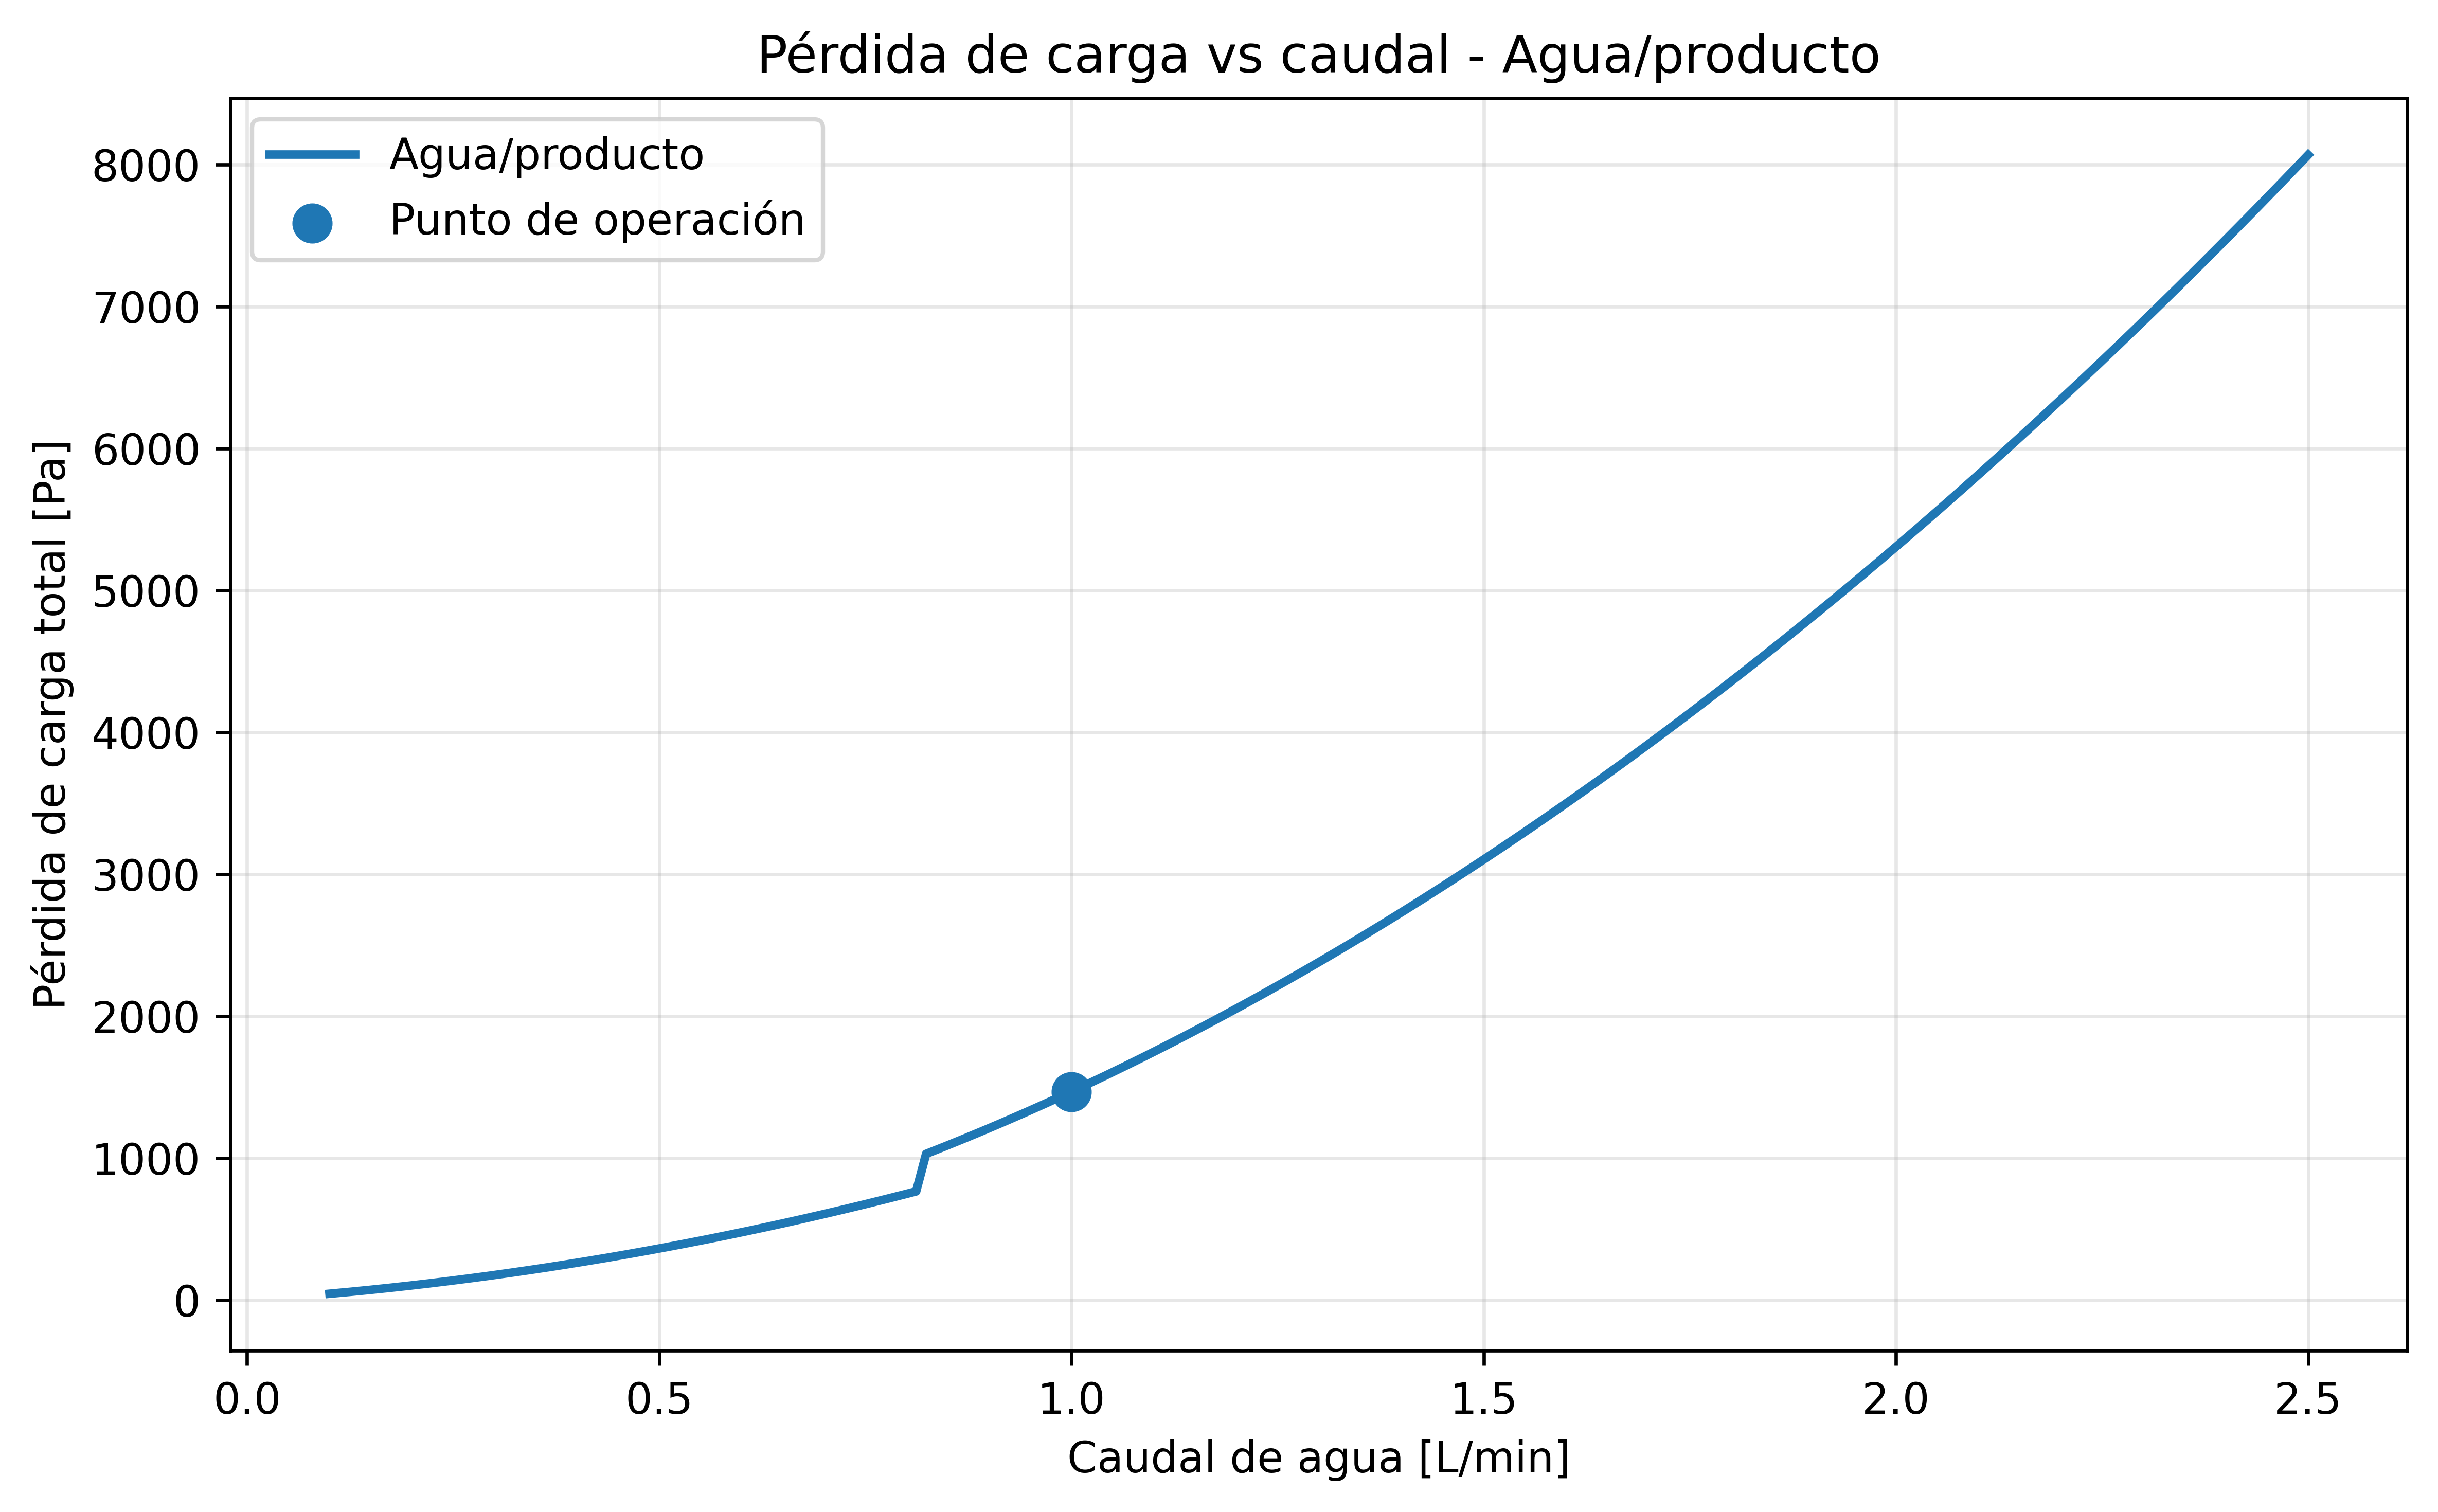

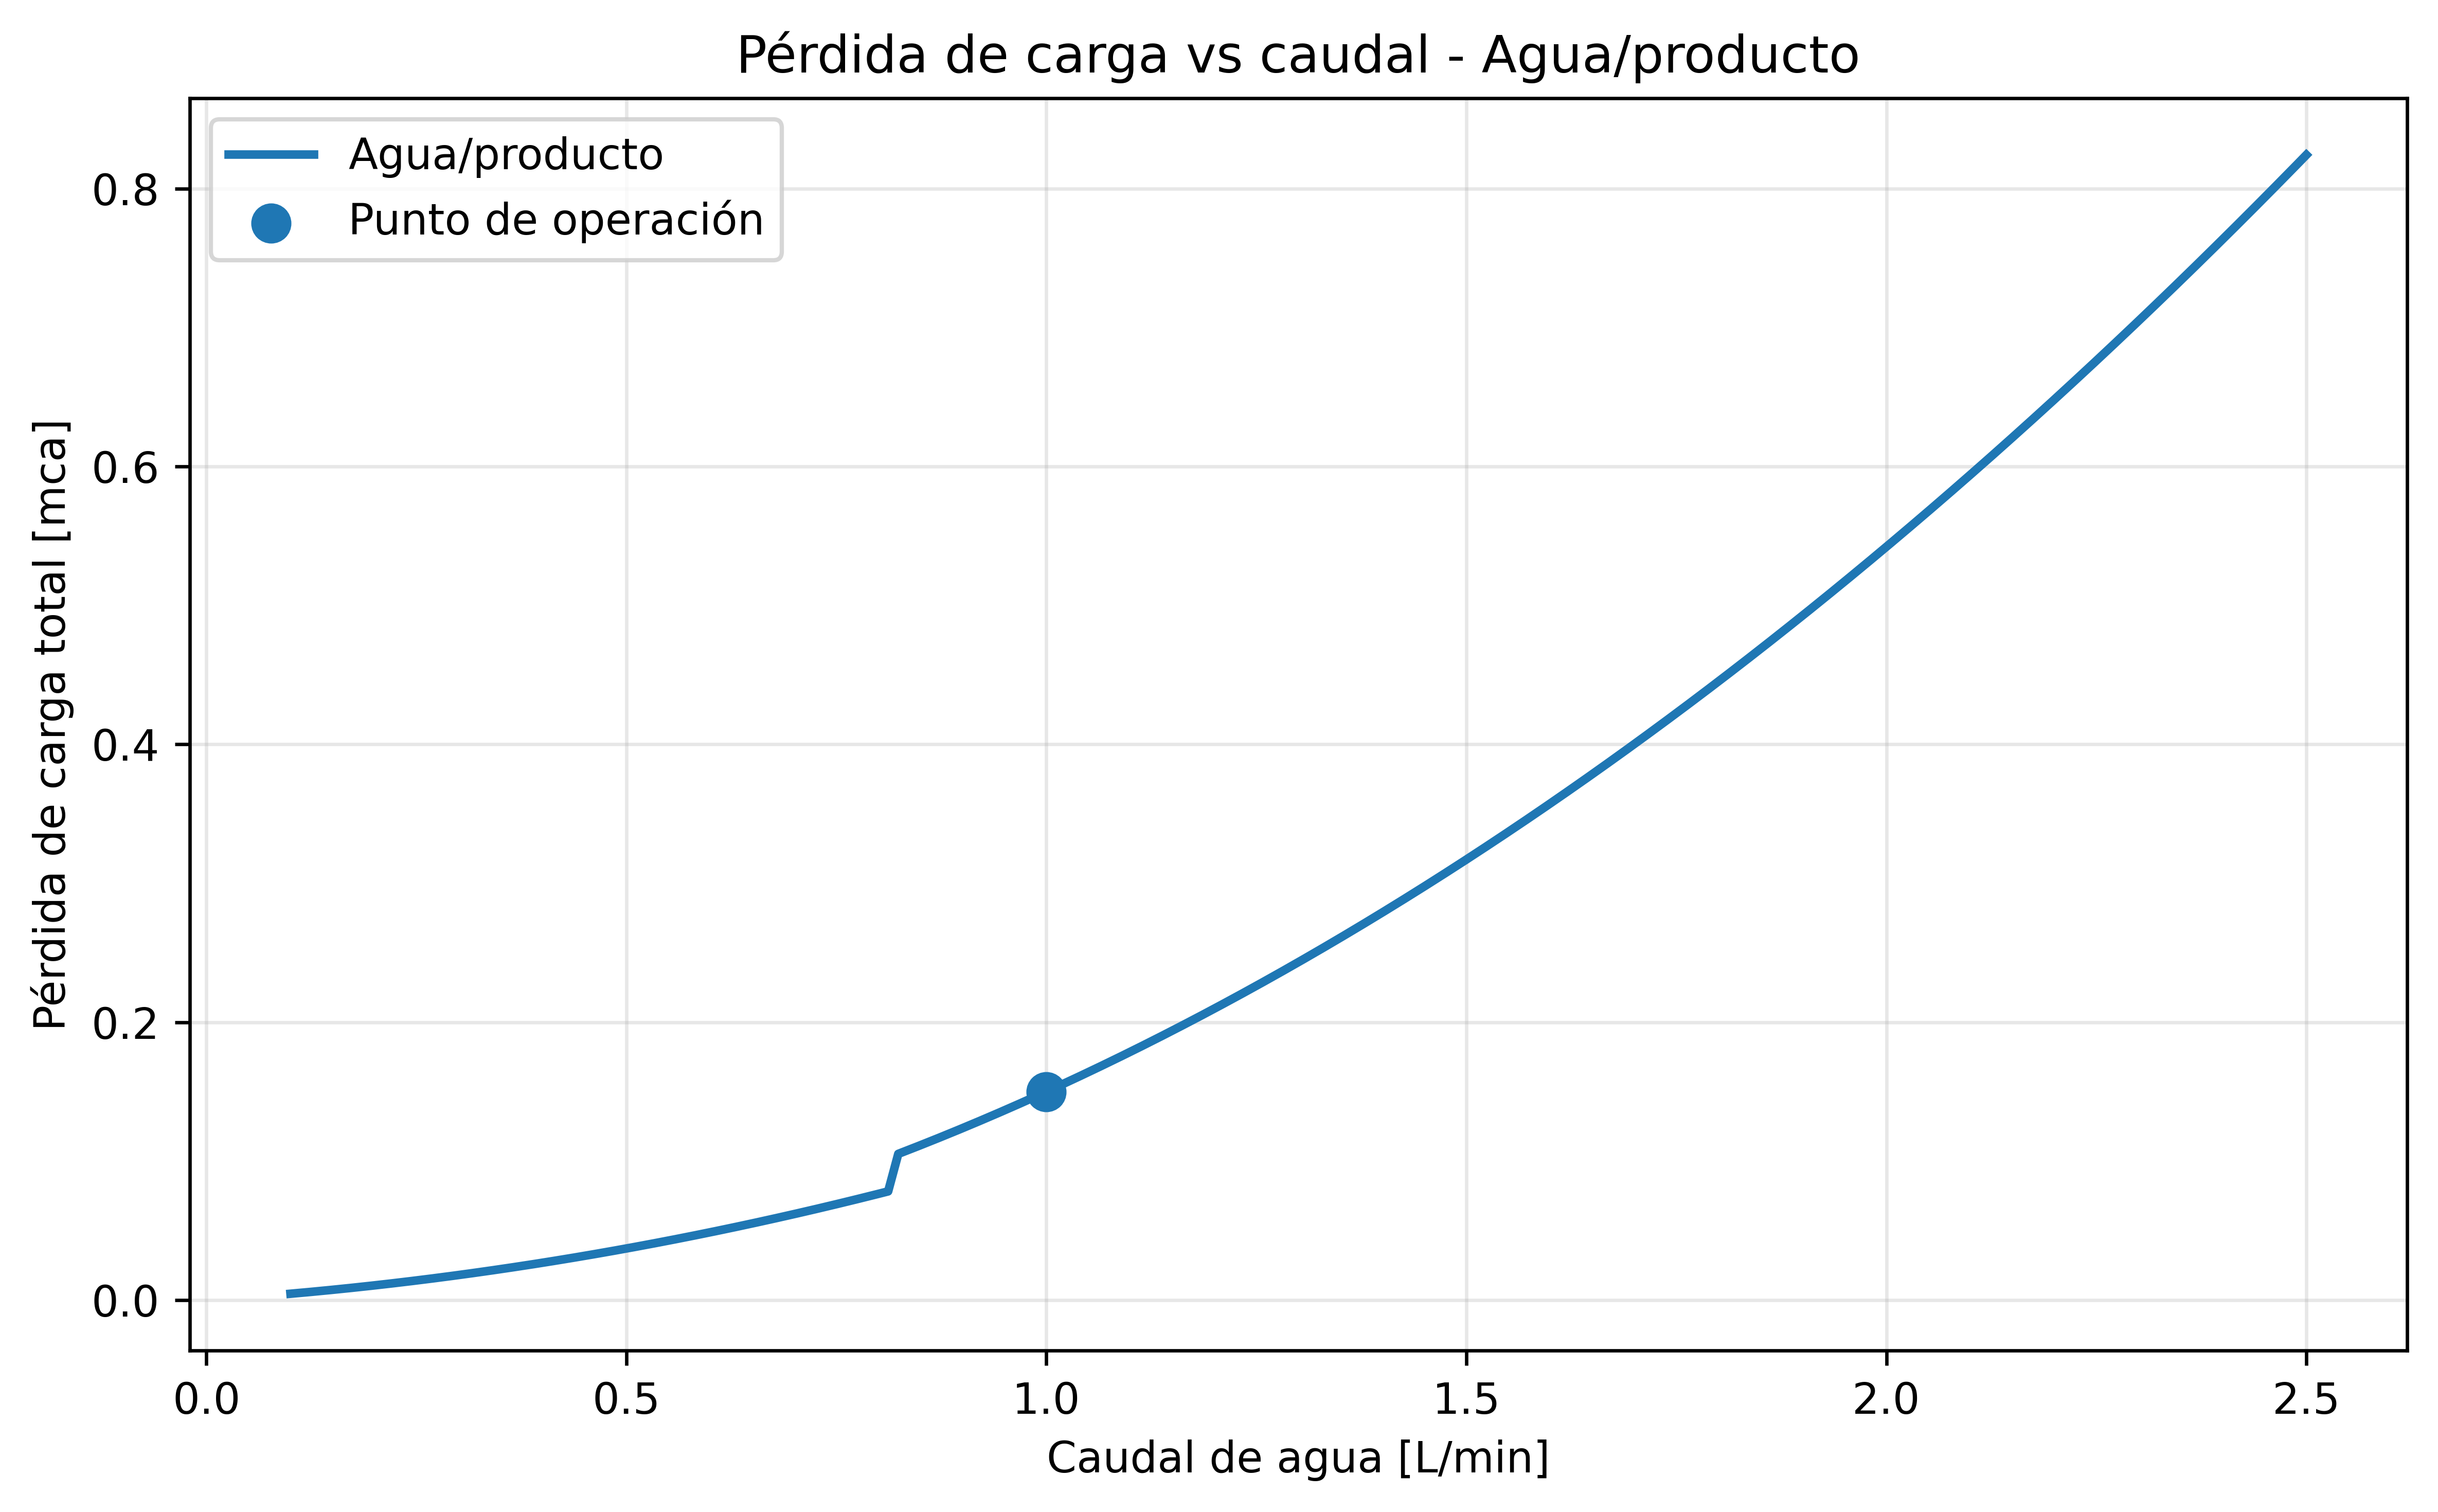

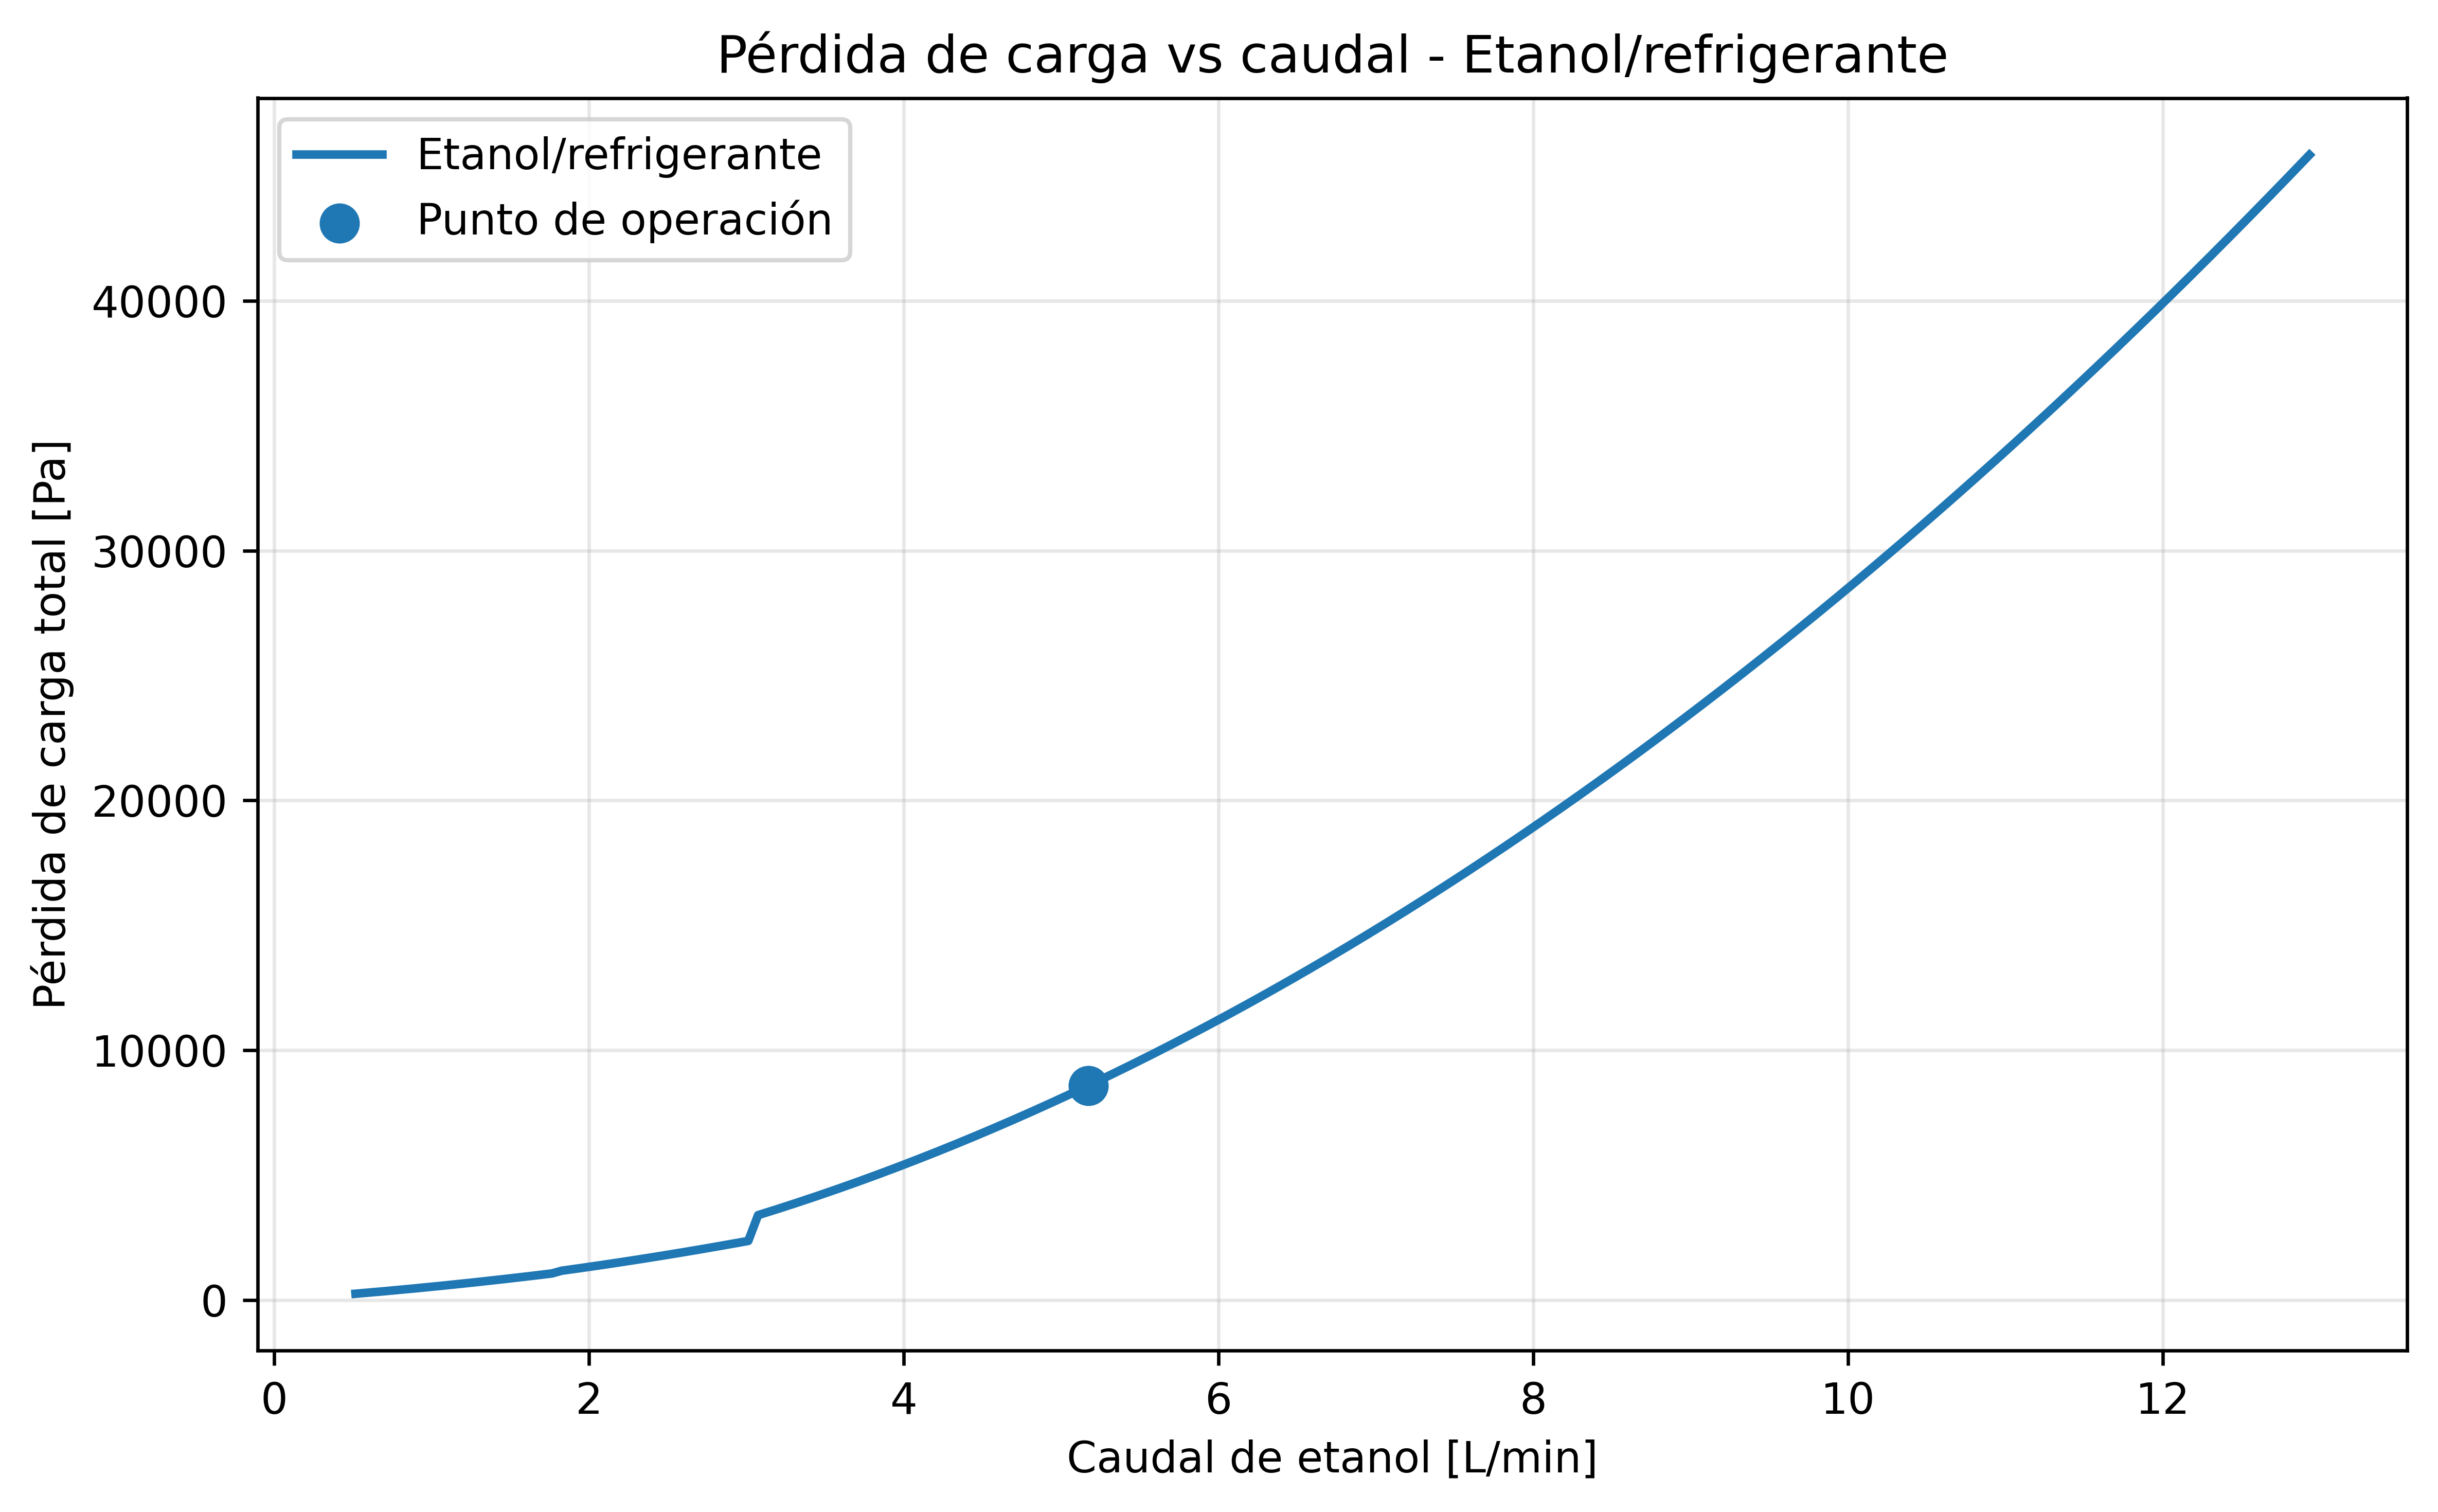

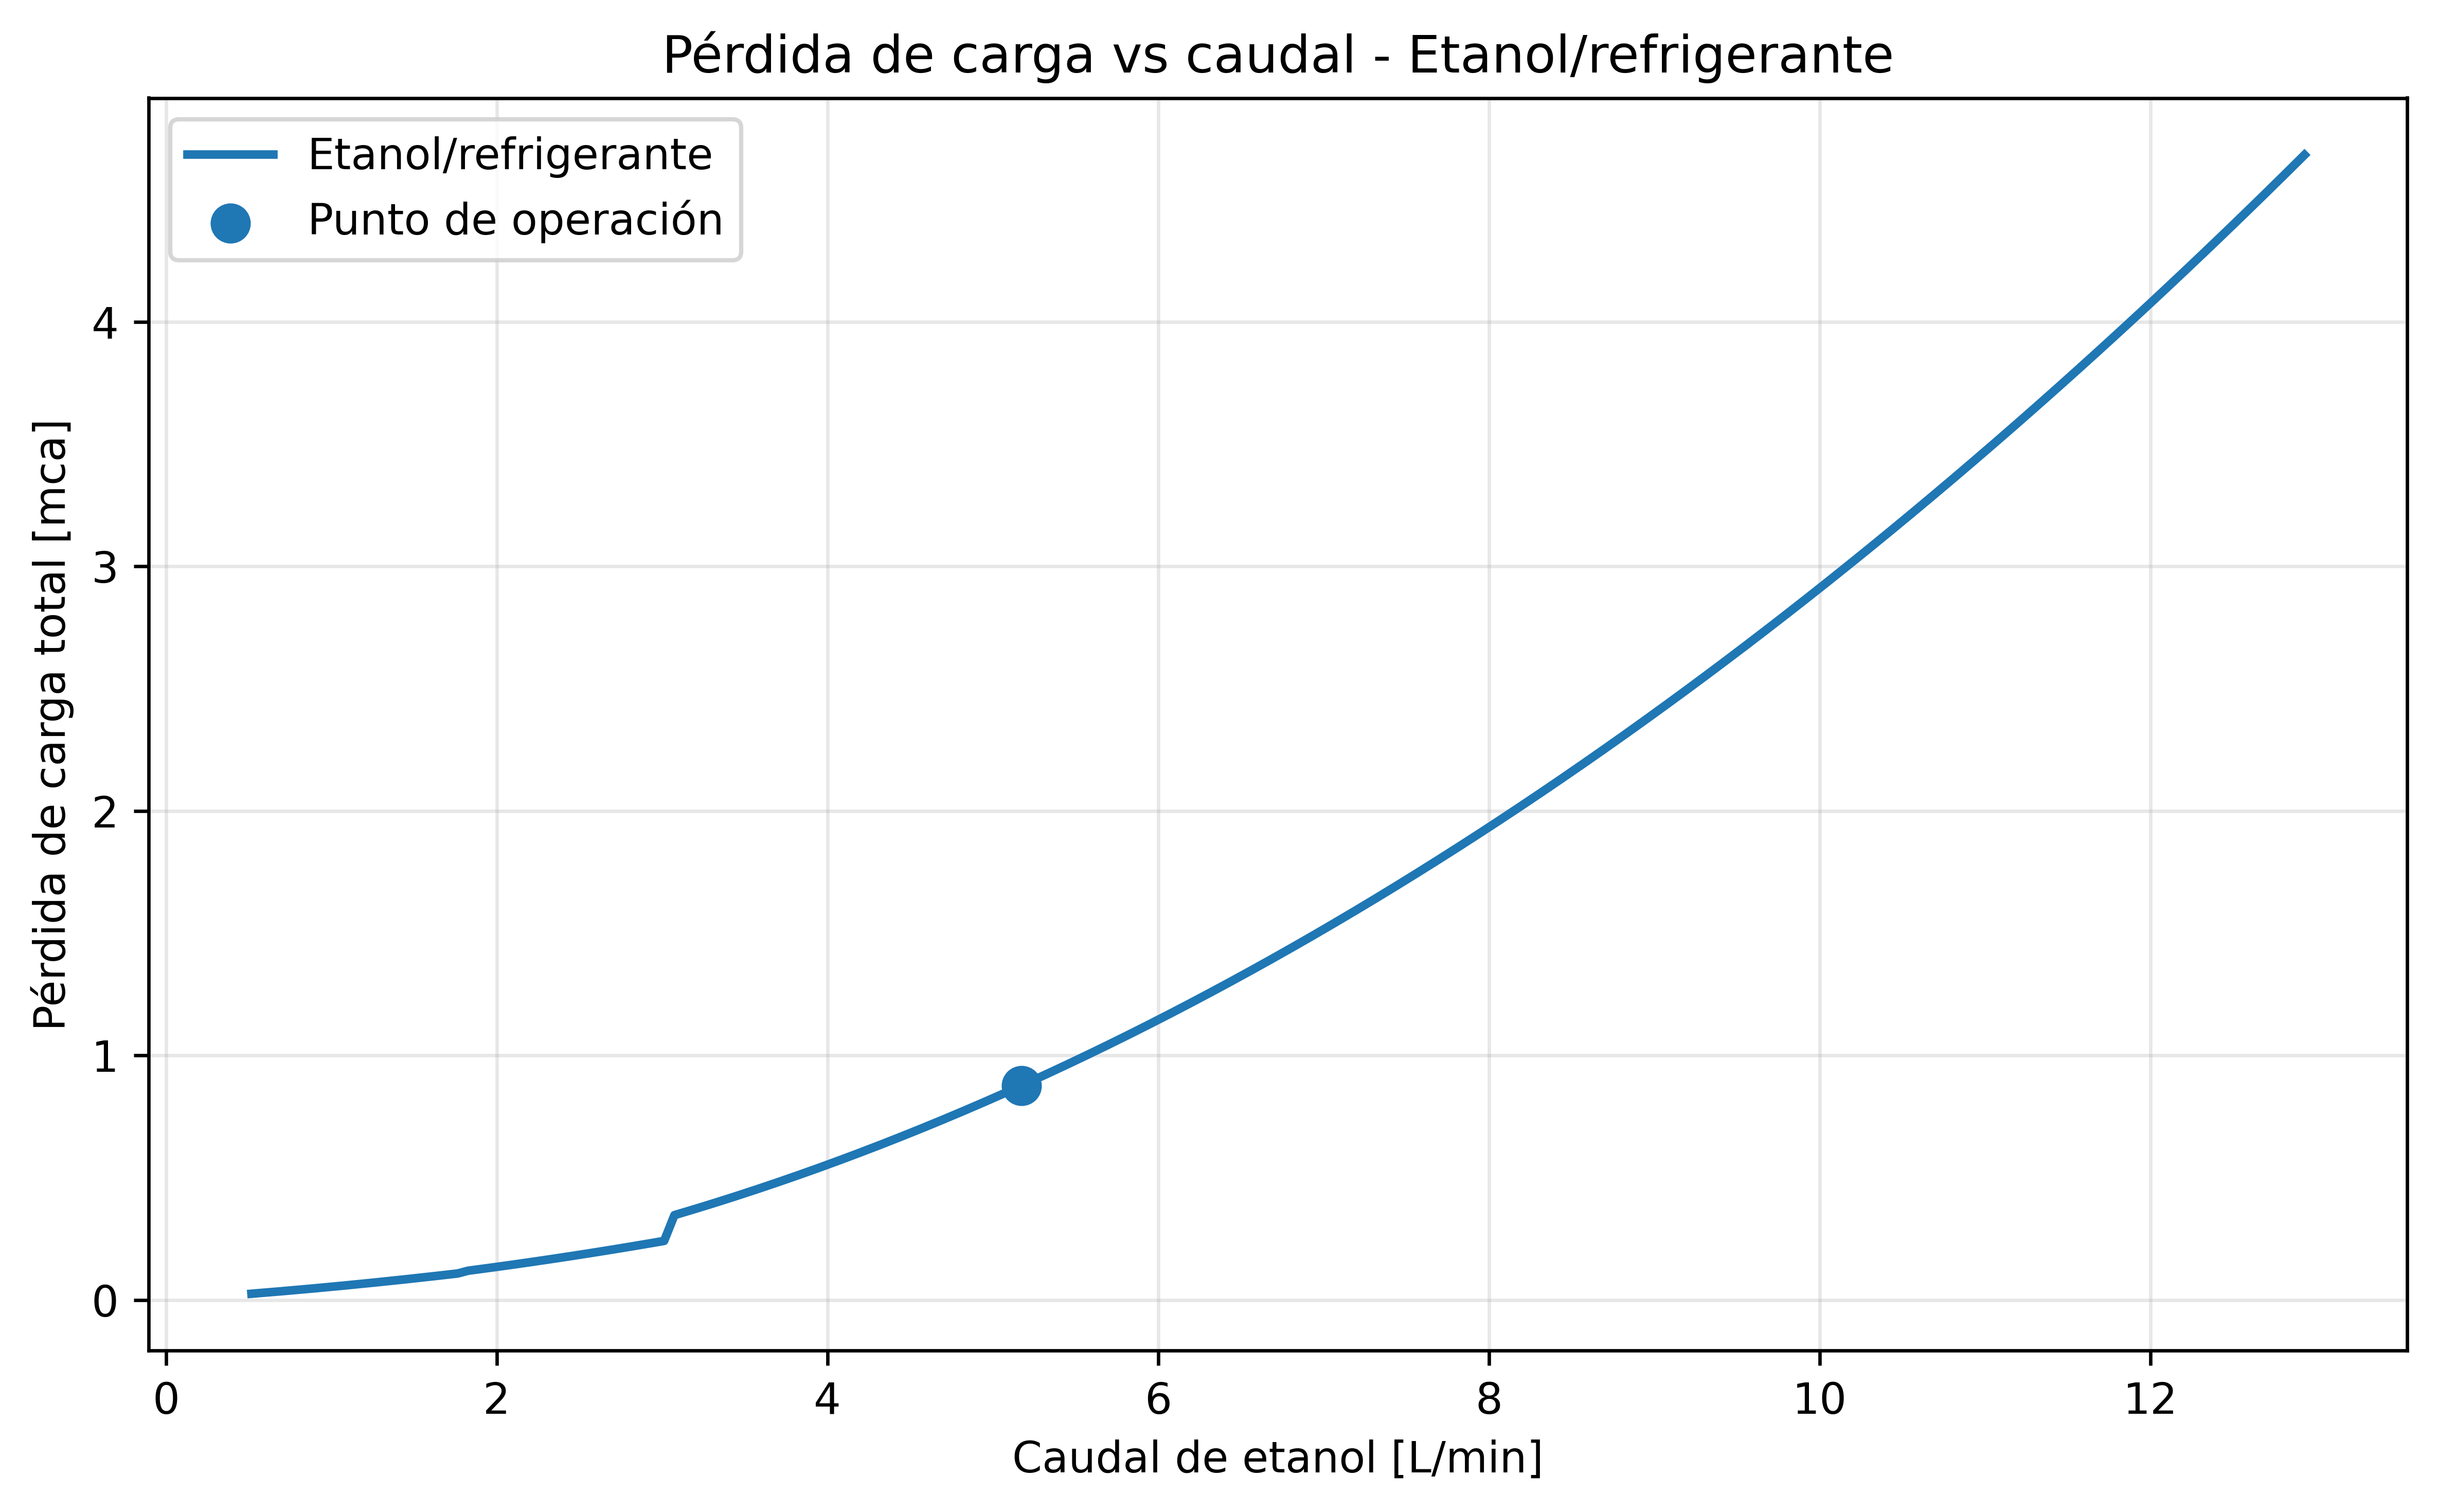

,Q_L_min,DeltaP_total_Pa,Perdida_mca
0,0.100000,45.058105,0.004602
1,0.112060,51.429891,0.005253
2,0.124121,58.003502,0.005925
3,0.136181,64.778937,0.006617
4,0.148241,71.756196,0.007329
...,...,...,...
195,2.451759,7778.476569,0.794502
196,2.463819,7850.625790,0.801871
197,2.475879,7923.095957,0.809274
198,2.487940,7995.886995,0.816709


,Q_L_min,DeltaP_total_Pa,Perdida_mca
0,0.517241,249.816354,0.025517
1,0.579622,283.383264,0.028945
2,0.642003,317.690257,0.032449
3,0.704384,352.737334,0.036029
4,0.766765,388.524494,0.039684
...,...,...,...
195,12.681511,44216.757180,4.516347
196,12.743892,44621.165780,4.557654
197,12.806273,45027.334201,4.599141
198,12.868654,45435.261995,4.640807


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CURVAS SEPARADAS: PÉRDIDA DE CARGA VS CAUDAL
# EN Pa Y mca
# ============================================================

def calcular_perdida_agua_vs_Q(Q):
    tramos = [
        perdida_tubo_circular(
            Q=Q,
            D=D_agua_silicona_in,
            L=L_agua_silicona_antes,
            rho=rho_agua,
            mu=mu_agua,
            eps=EPS_SILICONA,
            K=0.0,
            nombre="Agua/producto - manguera silicona antes HX",
        ),
        perdida_tubo_circular(
            Q=Q,
            D=D_inox_in,
            L=L_HX,
            rho=rho_agua,
            mu=mu_agua,
            eps=EPS_INOX,
            K=0.0,
            nombre="Agua/producto - tubo interno inox HX",
        ),
        perdida_tubo_circular(
            Q=Q,
            D=D_agua_silicona_in,
            L=L_agua_silicona_despues,
            rho=rho_agua,
            mu=mu_agua,
            eps=EPS_SILICONA,
            K=K_total_agua,
            nombre="Agua/producto - manguera silicona después HX + accesorios",
        ),
    ]

    df = pd.DataFrame(tramos)

    resumen = resumen_circuito(
        df_tramos=df,
        rho=rho_agua,
        delta_z=delta_z_agua,
        incluir_altura=INCLUIR_ALTURA,
    )

    dp_total = resumen["DeltaP total (Pa)"]

    return {
        "Q_L_min": Q * 60 * 1000,
        "DeltaP_total_Pa": dp_total,
        "Perdida_mca": dp_total / (rho_agua * g),   # metros de columna de agua
    }


def calcular_perdida_etanol_vs_Q(Q):
    tramos = [
        perdida_tubo_circular(
            Q=Q,
            D=D_etanol_silicona_in,
            L=L_etanol_silicona_antes,
            rho=rho_etanol,
            mu=mu_etanol,
            eps=EPS_SILICONA,
            K=0.0,
            nombre="Etanol/refrigerante - manguera silicona antes HX",
        ),
        perdida_tubo_anular(
            Q=Q,
            D_externo_interno=D_cobre_in,
            D_interno_externo=D_inox_out,
            L=L_etanol_HX,
            rho=rho_etanol,
            mu=mu_etanol,
            eps=EPS_ANULAR_ETANOL,
            K=K_total_etanol,
            nombre="Etanol/refrigerante - anular entre cobre externo e inox interno HX",
        ),
        perdida_tubo_circular(
            Q=Q,
            D=D_etanol_silicona_in,
            L=L_etanol_silicona_despues,
            rho=rho_etanol,
            mu=mu_etanol,
            eps=EPS_SILICONA,
            K=0.0,
            nombre="Etanol/refrigerante - manguera silicona después HX",
        ),
    ]

    df = pd.DataFrame(tramos)

    resumen = resumen_circuito(
        df_tramos=df,
        rho=rho_etanol,
        delta_z=delta_z_etanol,
        incluir_altura=INCLUIR_ALTURA,
    )

    dp_total = resumen["DeltaP total (Pa)"]

    return {
        "Q_L_min": Q * 60 * 1000,
        "DeltaP_total_Pa": dp_total,
        "Perdida_mca": dp_total / (rho_agua * g),   # convertido a mca
    }


# ============================================================
# RANGO DE CAUDALES
# ============================================================

factor_min = 0.10
factor_max = 2.50
n_puntos = 200

Q_agua_vec = np.linspace(factor_min * Q_agua, factor_max * Q_agua, n_puntos)
Q_etanol_vec = np.linspace(factor_min * Q_etanol, factor_max * Q_etanol, n_puntos)

df_agua_vs_Q = pd.DataFrame([calcular_perdida_agua_vs_Q(Q) for Q in Q_agua_vec])
df_etanol_vs_Q = pd.DataFrame([calcular_perdida_etanol_vs_Q(Q) for Q in Q_etanol_vec])

# Puntos de operación
dp_agua_op = resumen_agua["DeltaP total (Pa)"]
dp_etanol_op = resumen_etanol["DeltaP total (Pa)"]

mca_agua_op = dp_agua_op / (rho_agua * g)
mca_etanol_op = dp_etanol_op / (rho_agua * g)


# ============================================================
# FIGURA 1: AGUA EN Pa
# ============================================================

plt.figure(figsize=(8, 5), dpi=600)
plt.plot(
    df_agua_vs_Q["Q_L_min"],
    df_agua_vs_Q["DeltaP_total_Pa"],
    linewidth=2,
    label="Agua/producto"
)
plt.scatter(
    Q_agua * 60 * 1000,
    dp_agua_op,
    s=70,
    zorder=3,
    label="Punto de operación"
)
plt.xlabel("Caudal de agua [L/min]")
plt.ylabel("Pérdida de carga total [Pa]")
plt.title("Pérdida de carga vs caudal - Agua/producto")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# FIGURA 2: AGUA EN mca
# ============================================================

plt.figure(figsize=(8, 5), dpi=600)
plt.plot(
    df_agua_vs_Q["Q_L_min"],
    df_agua_vs_Q["Perdida_mca"],
    linewidth=2,
    label="Agua/producto"
)
plt.scatter(
    Q_agua * 60 * 1000,
    mca_agua_op,
    s=70,
    zorder=3,
    label="Punto de operación"
)
plt.xlabel("Caudal de agua [L/min]")
plt.ylabel("Pérdida de carga total [mca]")
plt.title("Pérdida de carga vs caudal - Agua/producto")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# FIGURA 3: ETANOL EN Pa
# ============================================================

plt.figure(figsize=(8, 5), dpi=600)
plt.plot(
    df_etanol_vs_Q["Q_L_min"],
    df_etanol_vs_Q["DeltaP_total_Pa"],
    linewidth=2,
    label="Etanol/refrigerante"
)
plt.scatter(
    Q_etanol * 60 * 1000,
    dp_etanol_op,
    s=70,
    zorder=3,
    label="Punto de operación"
)
plt.xlabel("Caudal de etanol [L/min]")
plt.ylabel("Pérdida de carga total [Pa]")
plt.title("Pérdida de carga vs caudal - Etanol/refrigerante")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# FIGURA 4: ETANOL EN mca
# ============================================================

plt.figure(figsize=(8, 5), dpi=600)
plt.plot(
    df_etanol_vs_Q["Q_L_min"],
    df_etanol_vs_Q["Perdida_mca"],
    linewidth=2,
    label="Etanol/refrigerante"
)
plt.scatter(
    Q_etanol * 60 * 1000,
    mca_etanol_op,
    s=70,
    zorder=3,
    label="Punto de operación"
)
plt.xlabel("Caudal de etanol [L/min]")
plt.ylabel("Pérdida de carga total [mca]")
plt.title("Pérdida de carga vs caudal - Etanol/refrigerante")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# TABLAS OPCIONALES
# ============================================================

display(df_agua_vs_Q.round(6))
display(df_etanol_vs_Q.round(6))

Caudal de operación estimado: 6.538 L/min
Pérdida de carga en operación: 13107.93 Pa
Pérdida de carga en operación: 1.3389 mca


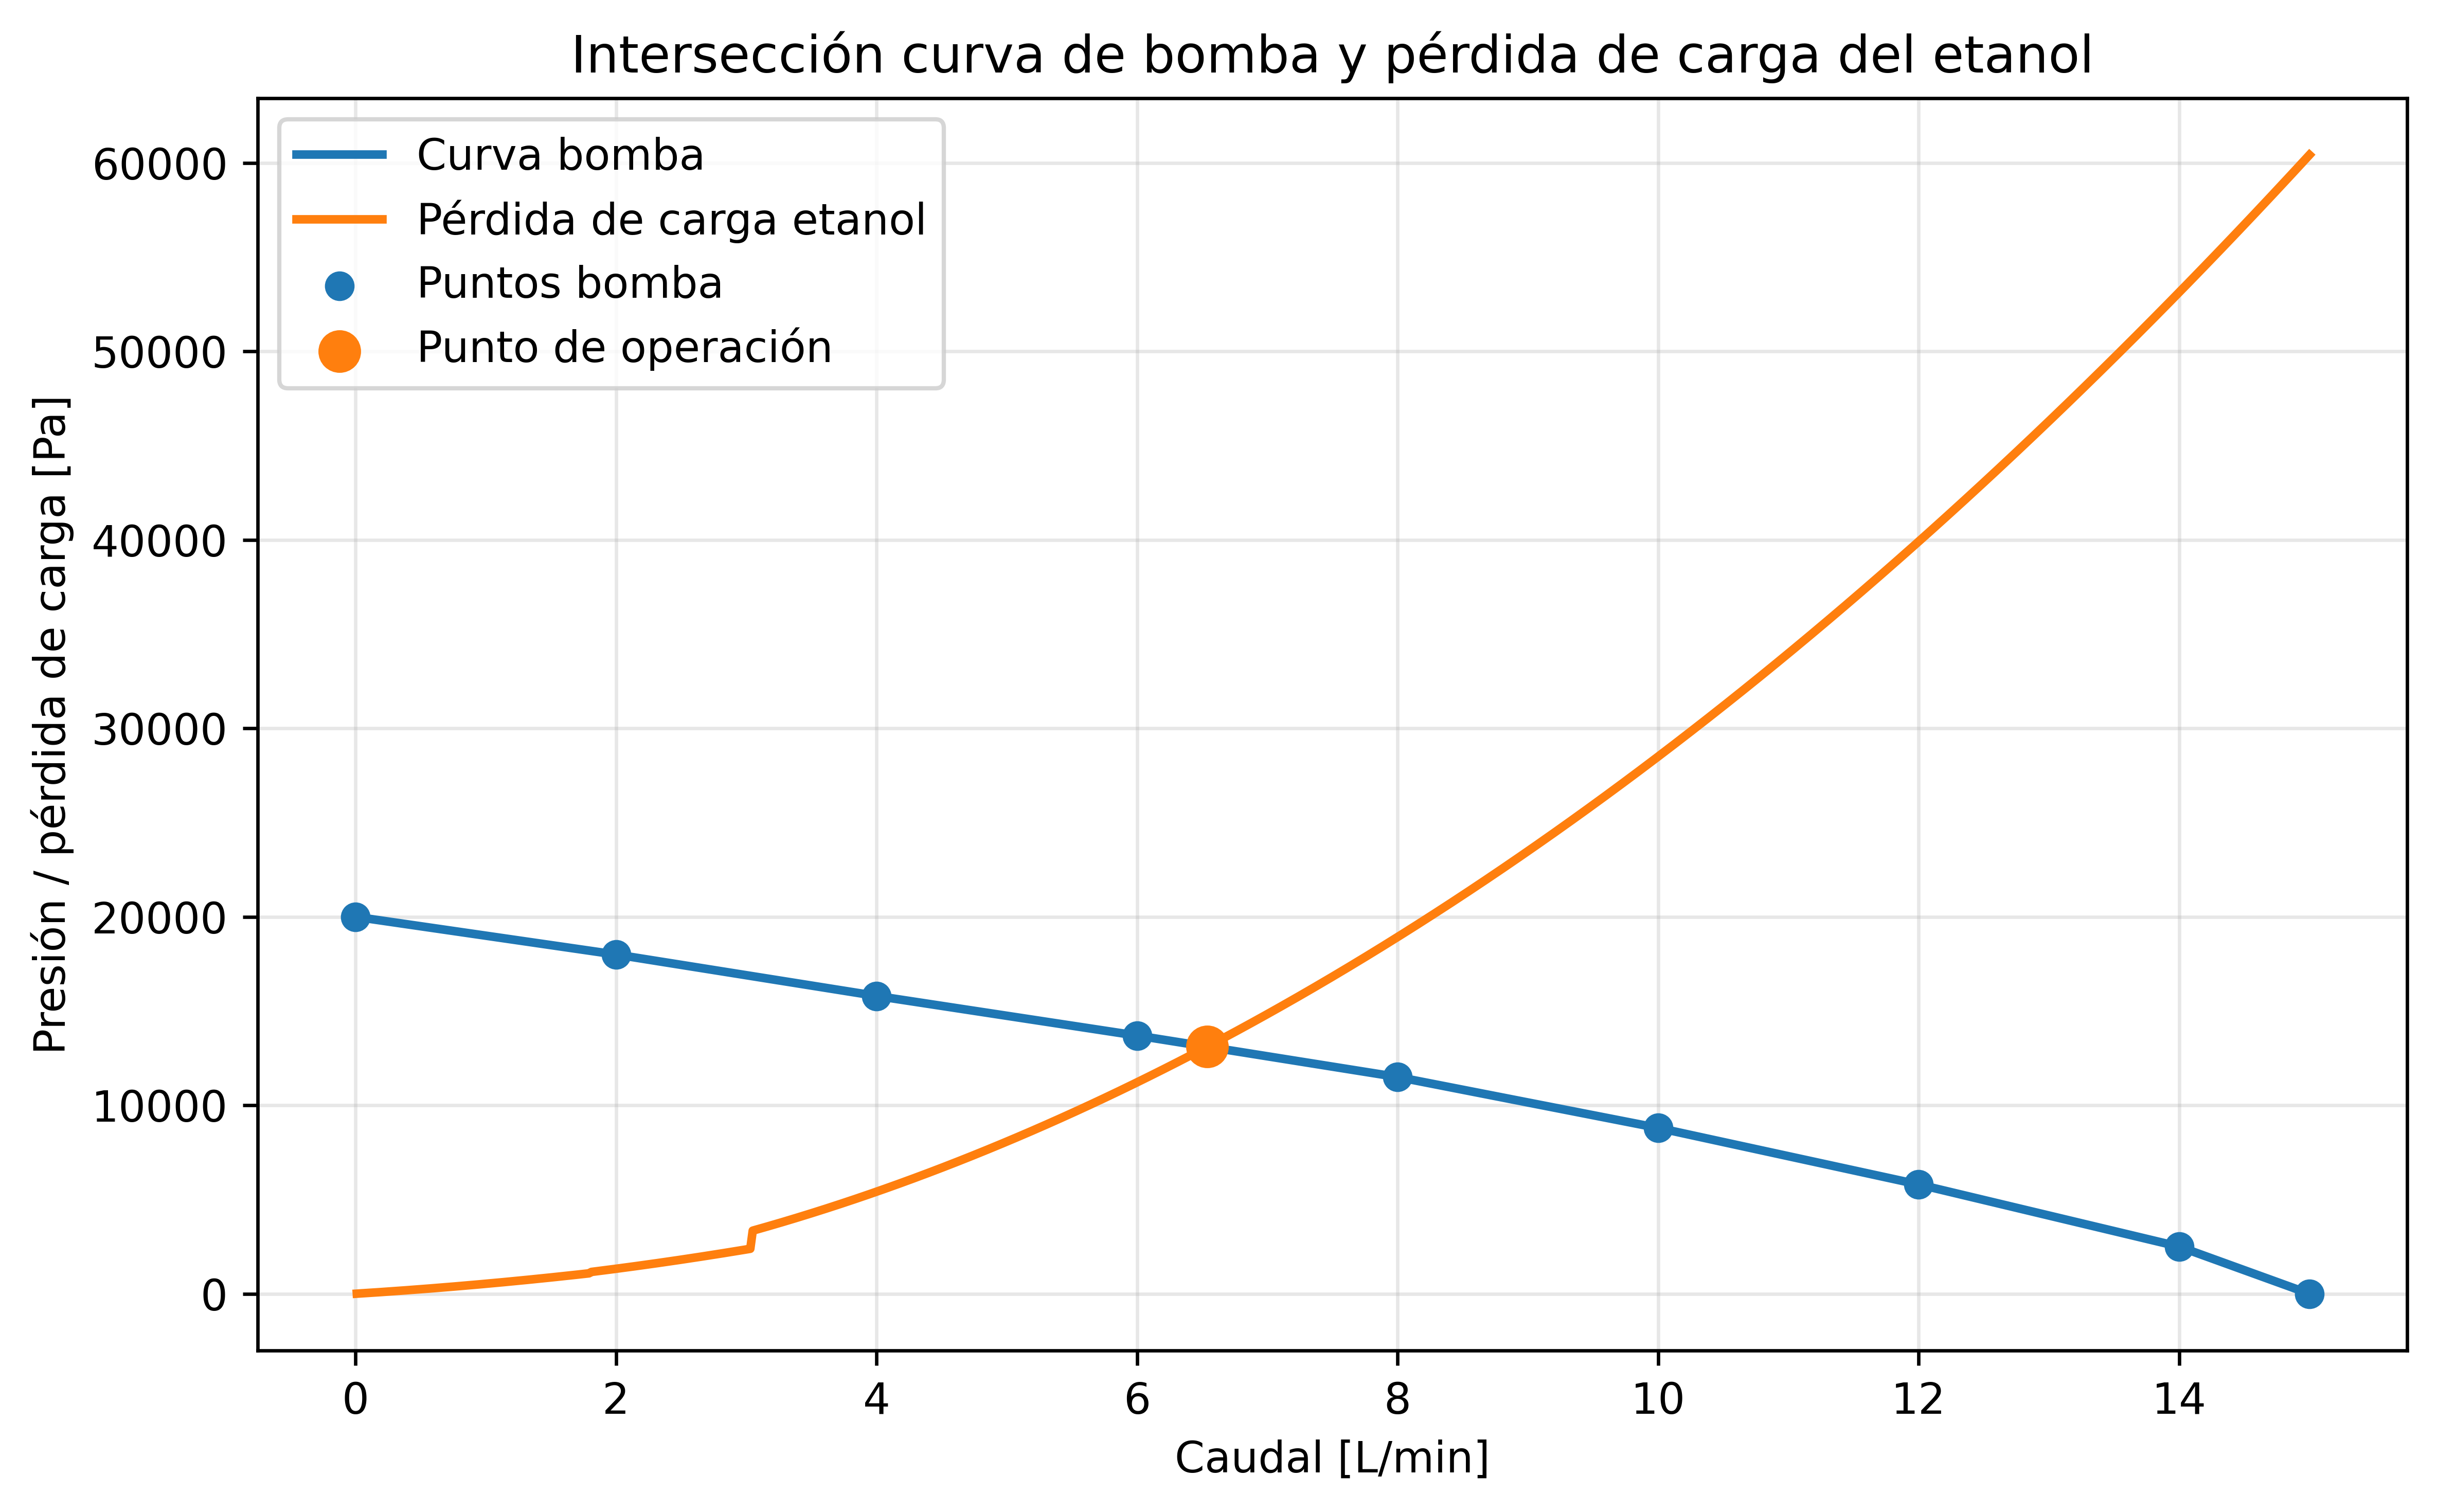

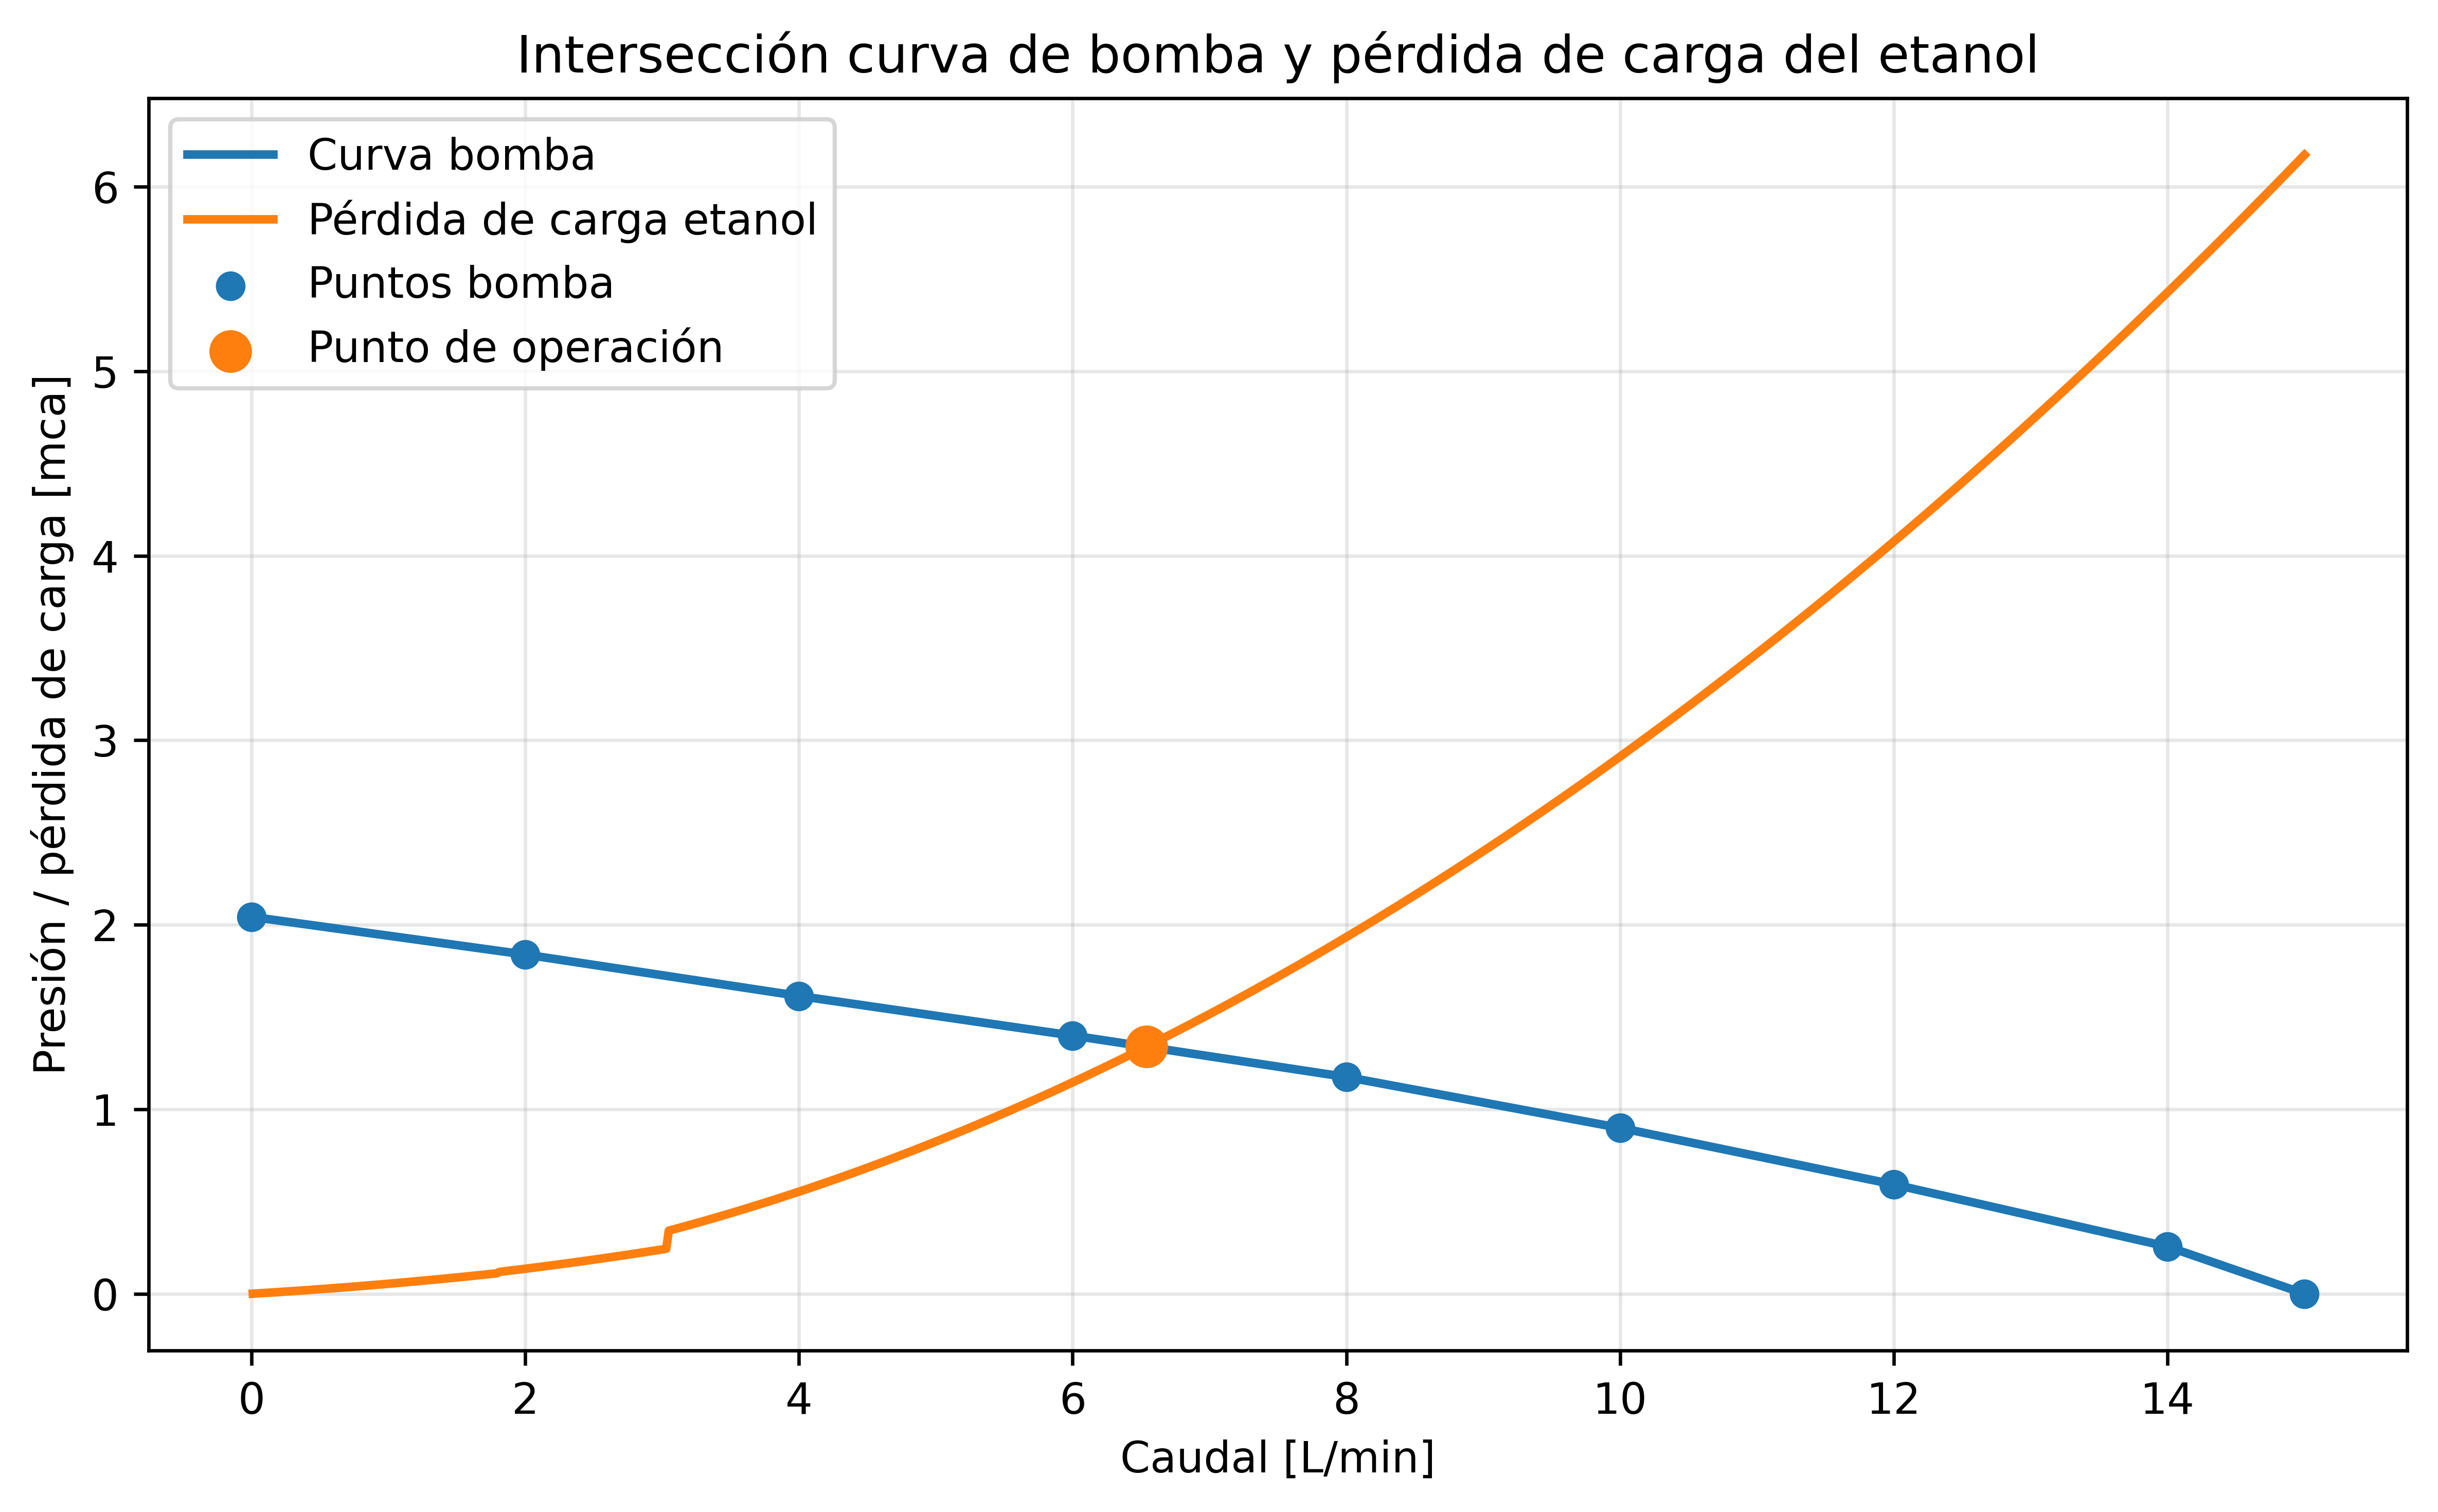

,Q_L_min,P_bar,DeltaP_bomba_Pa,DeltaP_bomba_mca
0,0.0,0.200,20000.0,2.042822
1,2.0,0.180,18000.0,1.838539
2,4.0,0.158,15800.0,1.613829
3,6.0,0.137,13700.0,1.399333
4,8.0,0.115,11500.0,1.174622
5,10.0,0.088,8800.0,0.898842
6,12.0,0.058,5800.0,0.592418
7,14.0,0.025,2500.0,0.255353
8,15.0,0.000,0.0,0.000000


,Q_operacion_L_min,DeltaP_operacion_Pa,DeltaP_operacion_mca
0,6.538247,13107.928154,1.338858


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# CURVA BOMBA MANUAL DESDE LA IMAGEN
# Unidades originales de la imagen: Q [L/min], presión [bar]
# ============================================================

Q_bomba_L_min = np.array([
    0.0, 2.0, 4.0, 6.0, 8.0, 10.0, 12.0, 14.0, 15.0
])

P_bomba_bar = np.array([
    0.200, 0.180, 0.158, 0.137, 0.115, 0.088, 0.058, 0.025, 0.000
])

df_bomba = pd.DataFrame({
    "Q_L_min": Q_bomba_L_min,
    "P_bar": P_bomba_bar,
})

df_bomba["DeltaP_bomba_Pa"] = df_bomba["P_bar"] * 1e5
df_bomba["DeltaP_bomba_mca"] = df_bomba["DeltaP_bomba_Pa"] / (rho_agua * g)


# ============================================================
# FUNCIÓN PÉRDIDA DE CARGA ETANOL
# ============================================================

def calcular_dp_etanol_total(Q):
    tramos = [
        perdida_tubo_circular(
            Q=Q,
            D=D_etanol_silicona_in,
            L=L_etanol_silicona_antes,
            rho=rho_etanol,
            mu=mu_etanol,
            eps=EPS_SILICONA,
            K=0.0,
            nombre="Etanol/refrigerante - manguera silicona antes HX",
        ),
        perdida_tubo_anular(
            Q=Q,
            D_externo_interno=D_cobre_in,
            D_interno_externo=D_inox_out,
            L=L_etanol_HX,
            rho=rho_etanol,
            mu=mu_etanol,
            eps=EPS_ANULAR_ETANOL,
            K=K_total_etanol,
            nombre="Etanol/refrigerante - anular HX",
        ),
        perdida_tubo_circular(
            Q=Q,
            D=D_etanol_silicona_in,
            L=L_etanol_silicona_despues,
            rho=rho_etanol,
            mu=mu_etanol,
            eps=EPS_SILICONA,
            K=0.0,
            nombre="Etanol/refrigerante - manguera silicona después HX",
        ),
    ]

    df = pd.DataFrame(tramos)

    resumen = resumen_circuito(
        df_tramos=df,
        rho=rho_etanol,
        delta_z=delta_z_etanol,
        incluir_altura=INCLUIR_ALTURA,
    )

    return resumen["DeltaP total (Pa)"]


# ============================================================
# CURVAS PARA INTERSECCIÓN
# ============================================================

Q_eval_L_min = np.linspace(0.01, 15.0, 800)
Q_eval_m3_s = Q_eval_L_min / 1000 / 60

DeltaP_etanol_Pa = np.array([
    calcular_dp_etanol_total(Q) for Q in Q_eval_m3_s
])

DeltaP_bomba_Pa = np.interp(
    Q_eval_L_min,
    df_bomba["Q_L_min"],
    df_bomba["DeltaP_bomba_Pa"],
)

DeltaP_etanol_mca = DeltaP_etanol_Pa / (rho_agua * g)
DeltaP_bomba_mca = DeltaP_bomba_Pa / (rho_agua * g)


# ============================================================
# INTERSECCIÓN BOMBA - SISTEMA
# ============================================================

diferencia = DeltaP_bomba_Pa - DeltaP_etanol_Pa
idx = np.where(np.diff(np.sign(diferencia)) != 0)[0]

if len(idx) == 0:
    Q_inter_L_min = np.nan
    DeltaP_inter_Pa = np.nan
    DeltaP_inter_mca = np.nan
    print("No hay intersección dentro del rango de la bomba.")
else:
    i = idx[0]

    x1 = Q_eval_L_min[i]
    x2 = Q_eval_L_min[i + 1]
    y1 = diferencia[i]
    y2 = diferencia[i + 1]

    Q_inter_L_min = x1 - y1 * (x2 - x1) / (y2 - y1)
    DeltaP_inter_Pa = np.interp(Q_inter_L_min, Q_eval_L_min, DeltaP_bomba_Pa)
    DeltaP_inter_mca = DeltaP_inter_Pa / (rho_agua * g)

    print(f"Caudal de operación estimado: {Q_inter_L_min:.3f} L/min")
    print(f"Pérdida de carga en operación: {DeltaP_inter_Pa:.2f} Pa")
    print(f"Pérdida de carga en operación: {DeltaP_inter_mca:.4f} mca")


# ============================================================
# GRÁFICO EN Pa
# ============================================================

plt.figure(figsize=(8, 5), dpi=600)

plt.plot(
    Q_eval_L_min,
    DeltaP_bomba_Pa,
    linewidth=2,
    label="Curva bomba"
)

plt.plot(
    Q_eval_L_min,
    DeltaP_etanol_Pa,
    linewidth=2,
    label="Pérdida de carga etanol"
)

plt.scatter(
    df_bomba["Q_L_min"],
    df_bomba["DeltaP_bomba_Pa"],
    s=35,
    zorder=3,
    label="Puntos bomba"
)

if not np.isnan(Q_inter_L_min):
    plt.scatter(
        Q_inter_L_min,
        DeltaP_inter_Pa,
        s=80,
        zorder=4,
        label="Punto de operación"
    )

plt.xlabel("Caudal [L/min]")
plt.ylabel("Presión / pérdida de carga [Pa]")
plt.title("Intersección curva de bomba y pérdida de carga del etanol")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# GRÁFICO EN mca
# ============================================================

plt.figure(figsize=(8, 5), dpi=600)

plt.plot(
    Q_eval_L_min,
    DeltaP_bomba_mca,
    linewidth=2,
    label="Curva bomba"
)

plt.plot(
    Q_eval_L_min,
    DeltaP_etanol_mca,
    linewidth=2,
    label="Pérdida de carga etanol"
)

plt.scatter(
    df_bomba["Q_L_min"],
    df_bomba["DeltaP_bomba_mca"],
    s=35,
    zorder=3,
    label="Puntos bomba"
)

if not np.isnan(Q_inter_L_min):
    plt.scatter(
        Q_inter_L_min,
        DeltaP_inter_mca,
        s=80,
        zorder=4,
        label="Punto de operación"
    )

plt.xlabel("Caudal [L/min]")
plt.ylabel("Presión / pérdida de carga [mca]")
plt.title("Intersección curva de bomba y pérdida de carga del etanol")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# ============================================================
# TABLAS
# ============================================================

df_interseccion = pd.DataFrame([{
    "Q_operacion_L_min": Q_inter_L_min,
    "DeltaP_operacion_Pa": DeltaP_inter_Pa,
    "DeltaP_operacion_mca": DeltaP_inter_mca,
}])

display(df_bomba.round(6))
display(df_interseccion.round(6))